In [ ]:
import pandas as pd
import requests
import time
import glob
import os
import contextily as ctx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import statsmodels.api as sm
from shapely.geometry import Polygon, Point, box
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.metrics import make_scorer, classification_report, confusion_matrix, f1_score, roc_auc_score, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
import geopandas as gpd
import contextily as ctx
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from scipy.special import logit, expit

In [ ]:
path = 'C:\\Users\\MSI-1\\OneDrive\\Desktop\\Data_Science\\CSVs'
all_files = glob.glob(os.path.join(path, "ebd_*.csv"))

if not all_files:
    print("Error: No CSV files found.")
    print("Please make sure your 11 CSV files are in the same folder as this script.")
else:
    print(f"Found {len(all_files)} files to combine:")
    for f in all_files:
        print(f"  - {f}")

    all_dfs = []

    # 2. Loop through each file
    for filename in all_files:
        try:
            print(f"Reading {filename}...")

            # --- FIX IS HERE ---
            # Added encoding='latin1' to handle the error
            # Added low_memory=False to silence the DtypeWarning
            df = pd.read_csv(filename, encoding='latin1', low_memory=False)

            # Extract the "Migration Year" from the filename
            base_name = os.path.basename(filename)
            start_date_str = base_name.split('_')[2]
            start_year = start_date_str[:4]
            end_year = int(start_year) + 1
            migration_year_label = f"{start_year}-{end_year}"

            df['MIGRATION_YEAR'] = migration_year_label

            all_dfs.append(df)
            print(f"  ...Success. Added MIGRATION_YEAR: {migration_year_label}")

        except Exception as e:
            print(f"Error reading {filename}: {e}")
            print("Skipping this file.")

    # 3. Combine all DataFrames into one
    if all_dfs:
        print("\nCombining all DataFrames into one...")
        aggregated_df = pd.concat(all_dfs, ignore_index=True)

        # 4. Save the new, big CSV file
        output_filename = 'all_data_aggregated.csv'
        aggregated_df.to_csv(output_filename, index=False)

        print("\n--- All Done! ---")
        print(f"Successfully created: {output_filename}")
        print(f"Total rows in new file: {len(aggregated_df)}")
        print(f"\nYour 'MIGRATION_YEAR' column looks like this:")
        print(aggregated_df['MIGRATION_YEAR'].value_counts())

    else:
        print("\nNo files were successfully read. No output file created.")

Found 11 files to combine:
  - C:\Users\MSI-1\OneDrive\Desktop\Data_Science\CSVs\ebd_IN-DL_201410_201503_smp_relAug-2025.csv
  - C:\Users\MSI-1\OneDrive\Desktop\Data_Science\CSVs\ebd_IN-DL_201510_201603_smp_relAug-2025.csv
  - C:\Users\MSI-1\OneDrive\Desktop\Data_Science\CSVs\ebd_IN-DL_201610_201703_smp_relAug-2025.csv
  - C:\Users\MSI-1\OneDrive\Desktop\Data_Science\CSVs\ebd_IN-DL_201710_201803_smp_relAug-2025.csv
  - C:\Users\MSI-1\OneDrive\Desktop\Data_Science\CSVs\ebd_IN-DL_201810_201903_smp_relAug-2025.csv
  - C:\Users\MSI-1\OneDrive\Desktop\Data_Science\CSVs\ebd_IN-DL_201910_202003_smp_relAug-2025.csv
  - C:\Users\MSI-1\OneDrive\Desktop\Data_Science\CSVs\ebd_IN-DL_202010_202103_smp_relAug-2025.csv
  - C:\Users\MSI-1\OneDrive\Desktop\Data_Science\CSVs\ebd_IN-DL_202110_202203_smp_relAug-2025.csv
  - C:\Users\MSI-1\OneDrive\Desktop\Data_Science\CSVs\ebd_IN-DL_202210_202303_relAug-2025.csv
  - C:\Users\MSI-1\OneDrive\Desktop\Data_Science\CSVs\ebd_IN-DL_202310_202403_smp_relAug-2025.c

In [ ]:
aggregated_df

,GLOBAL UNIQUE IDENTIFIER,LAST EDITED DATE,TAXONOMIC ORDER,CATEGORY,TAXON CONCEPT ID,COMMON NAME,SCIENTIFIC NAME,SUBSPECIES COMMON NAME,SUBSPECIES SCIENTIFIC NAME,EXOTIC CODE,...,NUMBER OBSERVERS,ALL SPECIES REPORTED,GROUP IDENTIFIER,HAS MEDIA,APPROVED,REVIEWED,REASON,CHECKLIST COMMENTS,SPECIES COMMENTS,MIGRATION_YEAR
0,URN:CornellLabOfOrnithology:EBIRD:OBS1498720599,04:50.1,6122,species,avibase-5ACF7FB3,Temminck's Stint,Calidris temminckii,NaN,NaN,NaN,...,2.0,0,NaN,1,1,0,NaN,old photograph,NaN,2014-2015
1,URN:CornellLabOfOrnithology:EBIRD:OBS1260620800,19:31.7,27592,species,avibase-4913F838,Indian Pied Starling,Gracupica contra,NaN,NaN,NaN,...,NaN,1,NaN,1,1,0,NaN,Historical checklist created by eBird/Macaulay...,NaN,2014-2015
2,URN:CornellLabOfOrnithology:EBIRD:OBS1313289237,57:43.1,7562,species,avibase-F2858F9F,Little Egret,Egretta garzetta,NaN,NaN,NaN,...,2.0,1,NaN,1,1,0,NaN,NaN,NaN,2014-2015
3,URN:CornellLabOfOrnithology:EBIRD:OBS1260620803,14:35.0,6656,species,avibase-A874F334,River Tern,Sterna aurantia,NaN,NaN,NaN,...,NaN,1,NaN,1,1,0,NaN,Historical checklist created by eBird/Macaulay...,NaN,2014-2015
4,URN:CornellLabOfOrnithology:EBIRD:OBS287197030,57:43.0,7811,species,avibase-1192205B,Oriental Honey-buzzard,Pernis ptilorhynchus,NaN,NaN,NaN,...,2.0,1,G1081583,0,1,0,NaN,NaN,NaN,2014-2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447507,URN:CornellLabOfOrnithology:EBIRD:OBS3007998789,20:04.6,2487,species,avibase-F6C3F6DB,Yellow-footed Green-Pigeon,Treron phoenicopterus,NaN,NaN,NaN,...,1.0,1,NaN,0,1,0,NaN,NaN,NaN,2024-2025
447508,URN:CornellLabOfOrnithology:EBIRD:OBS2928902076,11:19.9,2487,species,avibase-F6C3F6DB,Yellow-footed Green-Pigeon,Treron phoenicopterus,NaN,NaN,NaN,...,1.0,1,NaN,0,1,0,NaN,NaN,NaN,2024-2025
447509,URN:CornellLabOfOrnithology:EBIRD:OBS3008010039,23:29.6,2487,species,avibase-F6C3F6DB,Yellow-footed Green-Pigeon,Treron phoenicopterus,NaN,NaN,NaN,...,1.0,1,NaN,0,1,0,NaN,NaN,NaN,2024-2025
447510,URN:CornellLabOfOrnithology:EBIRD:OBS2951716832,41:13.6,2487,species,avibase-F6C3F6DB,Yellow-footed Green-Pigeon,Treron phoenicopterus,NaN,NaN,NaN,...,1.0,1,NaN,0,1,0,NaN,NaN,NaN,2024-2025


In [ ]:
print("--- Step 1: Fetching External Data (Weather & Pollution) ---")

def fetch_historical_weather(start_date, end_date, lat=28.61, lon=77.23):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max",
        "timezone": "auto"
    }
    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        daily = data['daily']
        df = pd.DataFrame({
            'DATE': daily['time'],
            'TEMP_MAX': daily['temperature_2m_max'],
            'TEMP_MIN': daily['temperature_2m_min'],
            'PRECIPITATION': daily['precipitation_sum'],
            'WIND_SPEED': daily['wind_speed_10m_max']
        })
        return df
    else:
        print("Error fetching Weather:", response.text)
        return pd.DataFrame()

def fetch_historical_pollution(start_date, end_date, lat=28.61, lon=77.23):
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "pm10,pm2_5,european_aqi",
        "timezone": "auto"
    }
    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        hourly = data['hourly']
        df = pd.DataFrame({
            'DATETIME': pd.to_datetime(hourly['time']),
            'PM10': hourly['pm10'],
            'PM2_5': hourly['pm2_5'],
            'AQI': hourly['european_aqi']
        })
        # Resample to Daily Average
        df['DATE'] = df['DATETIME'].dt.date.astype(str)
        df_daily = df.groupby('DATE')[['PM10', 'PM2_5', 'AQI']].mean().reset_index()
        return df_daily
    else:
        print(f"Error fetching Pollution (Status {response.status_code})")
        return pd.DataFrame()

# Define Range
start = "2014-01-01"
end = "2025-01-01"

# Fetch Weather
print("Fetching Weather Data...")
df_weather = fetch_historical_weather(start, end)

# Fetch Pollution (Data usually starts ~Nov 2020)
print("Fetching Pollution Data...")
df_pollution = fetch_historical_pollution("2020-11-30", end)

print(f"Weather records: {len(df_weather)}")
print(f"Pollution records: {len(df_pollution)}")

--- Step 1: Fetching External Data (Weather & Pollution) ---
Fetching Weather Data...
Fetching Pollution Data...
Weather records: 4019
Pollution records: 1494


In [ ]:
print("\n--- Step 2: Processing Bird Data ---")

# NOTE: Ensure 'aggregated_df' is loaded in your environment before running this.
# If it's a CSV, uncomment the line below:
# aggregated_df = pd.read_csv('your_aggregated_data.csv')

df = aggregated_df.copy() # Use a copy to be safe

original_rows = len(df)
df_complete = df[df['ALL SPECIES REPORTED'] == 1].copy()
print(f"Filtered for complete checklists. Kept {len(df_complete)} rows out of {original_rows}.")

if len(df_complete) == 0:
    print("Error: No complete checklists found.")
    exit()

# Select Relevant Columns
relevant_columns = [
    'SAMPLING EVENT IDENTIFIER', 'MIGRATION_YEAR', 'COMMON NAME',
    'SCIENTIFIC NAME', 'OBSERVATION COUNT', 'OBSERVATION DATE',
    'TIME OBSERVATIONS STARTED', 'PROTOCOL NAME', 'LATITUDE',
    'LONGITUDE', 'DURATION MINUTES', 'EFFORT DISTANCE KM',
    'NUMBER OBSERVERS'
]
available_columns = [col for col in relevant_columns if col in df_complete.columns]
df_clean = df_complete[available_columns].copy()

# Convert Data Types
print("Converting data types...")
df_clean['OBSERVATION DATE'] = pd.to_datetime(df_clean['OBSERVATION DATE'])
df_clean['OBSERVATION COUNT'] = pd.to_numeric(df_clean['OBSERVATION COUNT'], errors='coerce').fillna(1)

for col in ['DURATION MINUTES', 'EFFORT DISTANCE KM', 'NUMBER OBSERVERS']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        # Handle Missing Values
        mean_val = df_clean[col].mean()
        df_clean[col] = df_clean[col].fillna(mean_val)

# Feature Engineering: Time
print("Engineering time-based features...")
df_clean['WEEK_OF_YEAR'] = df_clean['OBSERVATION DATE'].dt.isocalendar().week
df_clean['DAY_OF_YEAR'] = df_clean['OBSERVATION DATE'].dt.dayofyear

# Feature Engineering: Time of Day
try:
    # Try extracting from full datetime or just time string
    hour = pd.to_datetime(df_clean['TIME OBSERVATIONS STARTED'], format='%H:%M:%S', errors='coerce').dt.hour
    if hour.isnull().all():
         hour = pd.to_datetime(df_clean['TIME OBSERVATIONS STARTED'], format='%H:%M', errors='coerce').dt.hour

    bins = [0, 5, 10, 16, 24]
    labels = ['Night/Dawn', 'Morning', 'Midday/Afternoon', 'Evening']
    df_clean['TIME_OF_DAY'] = pd.cut(hour, bins=bins, labels=labels, right=False, include_lowest=True)
except Exception as e:
    print(f" - Could not engineer 'TIME_OF_DAY': {e}")

# Feature Engineering: Season Week
print("Engineering 'SEASON_WEEK'...")
start_year = df_clean['MIGRATION_YEAR'].str.slice(0, 4).astype(int)
season_start_date = pd.to_datetime(start_year.astype(str) + '-10-01')
time_delta = df_clean['OBSERVATION DATE'] - season_start_date
df_clean['SEASON_WEEK'] = (time_delta.dt.days // 7) + 1


--- Step 2: Processing Bird Data ---
Filtered for complete checklists. Kept 418601 rows out of 447512.
Converting data types...
Engineering time-based features...
Engineering 'SEASON_WEEK'...


In [ ]:
print("\n--- Step 3: Merging Weather & Pollution into Bird Data ---")

# 1. Standardize Date Formats for Merging
# We convert everything to datetime and normalize (remove time info) to ensure perfect matching
df_clean['temp_merge_date'] = pd.to_datetime(df_clean['OBSERVATION DATE']).dt.normalize()

if not df_weather.empty:
    df_weather['DATE'] = pd.to_datetime(df_weather['DATE']).dt.normalize()
if not df_pollution.empty:
    df_pollution['DATE'] = pd.to_datetime(df_pollution['DATE']).dt.normalize()

# 2. Merge Weather (Left Join: Keep all bird data, add weather where available)
print("Merging Weather...")
df_merged = pd.merge(
    df_clean,
    df_weather,
    left_on='temp_merge_date',
    right_on='DATE',
    how='left'
)
# Drop the extra 'DATE' column from weather
df_merged.drop(columns=['DATE'], inplace=True, errors='ignore')

# 3. Merge Pollution (Left Join)
print("Merging Pollution...")
df_merged = pd.merge(
    df_merged,
    df_pollution,
    left_on='temp_merge_date',
    right_on='DATE',
    how='left'
)
# Drop the extra 'DATE' column from pollution and our temporary merge column
df_merged.drop(columns=['DATE', 'temp_merge_date'], inplace=True, errors='ignore')


--- Step 3: Merging Weather & Pollution into Bird Data ---
Merging Weather...
Merging Pollution...


In [ ]:
output_filename = 'analysis_ready_data.csv'
df_merged.to_csv(output_filename, index=False)

print("\n--- All Done! ---")
print(f"Successfully created: {output_filename}")
print(f"Final columns: {list(df_merged.columns)}")
print("\nSample Data with Weather/Pollution:")
# Show sample to verify the merge worked (NaNs are expected for pollution before 2020)
print(df_merged[['OBSERVATION DATE', 'TEMP_MAX', 'AQI', 'SEASON_WEEK']].head())


--- All Done! ---
Successfully created: analysis_ready_data.csv
Final columns: ['SAMPLING EVENT IDENTIFIER', 'MIGRATION_YEAR', 'COMMON NAME', 'SCIENTIFIC NAME', 'OBSERVATION COUNT', 'OBSERVATION DATE', 'TIME OBSERVATIONS STARTED', 'PROTOCOL NAME', 'LATITUDE', 'LONGITUDE', 'DURATION MINUTES', 'EFFORT DISTANCE KM', 'NUMBER OBSERVERS', 'WEEK_OF_YEAR', 'DAY_OF_YEAR', 'TIME_OF_DAY', 'SEASON_WEEK', 'TEMP_MAX', 'TEMP_MIN', 'PRECIPITATION', 'WIND_SPEED', 'PM10', 'PM2_5', 'AQI']

Sample Data with Weather/Pollution:
  OBSERVATION DATE  TEMP_MAX  AQI  SEASON_WEEK
0       2014-10-08      34.7  NaN            2
1       2014-10-11      34.5  NaN            2
2       2014-10-18      30.9  NaN            3
3       2014-12-27      19.7  NaN           13
4       2014-12-07      26.1  NaN           10


In [ ]:
df_clean = df_merged
df_clean

,SAMPLING EVENT IDENTIFIER,MIGRATION_YEAR,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,OBSERVATION DATE,TIME OBSERVATIONS STARTED,PROTOCOL NAME,LATITUDE,LONGITUDE,...,DAY_OF_YEAR,TIME_OF_DAY,SEASON_WEEK,TEMP_MAX,TEMP_MIN,PRECIPITATION,WIND_SPEED,PM10,PM2_5,AQI
0,S96352034,2014-2015,Indian Pied Starling,Gracupica contra,1.0,2014-10-08,NaN,Historical,28.671858,77.237242,...,281,NaN,2,34.7,25.1,0.0,12.1,NaN,NaN,NaN
1,S100319446,2014-2015,Little Egret,Egretta garzetta,1.0,2014-10-11,15:30:00,Traveling,28.595167,77.221334,...,284,Midday/Afternoon,2,34.5,21.0,0.0,11.0,NaN,NaN,NaN
2,S96352035,2014-2015,River Tern,Sterna aurantia,1.0,2014-10-18,NaN,Historical,28.671858,77.237242,...,291,NaN,3,30.9,17.3,0.0,10.7,NaN,NaN,NaN
3,S21038397,2014-2015,Oriental Honey-buzzard,Pernis ptilorhynchus,1.0,2014-12-27,8:45:00,Traveling,28.535204,77.180757,...,361,Morning,13,19.7,8.2,0.0,13.8,NaN,NaN,NaN
4,S20818360,2014-2015,Green Sandpiper,Tringa ochropus,1.0,2014-12-07,9:00:00,Traveling,28.696987,77.239680,...,341,Morning,10,26.1,13.3,0.0,16.6,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418596,S221787904,2024-2025,Yellow-footed Green-Pigeon,Treron phoenicopterus,2.0,2025-03-26,7:25:00,Stationary,28.643769,77.069175,...,85,Morning,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
418597,S216527138,2024-2025,Yellow-footed Green-Pigeon,Treron phoenicopterus,4.0,2025-03-04,7:15:00,Stationary,28.644360,77.071654,...,63,Morning,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
418598,S221789176,2024-2025,Yellow-footed Green-Pigeon,Treron phoenicopterus,1.0,2025-03-27,8:05:00,Stationary,28.643769,77.069175,...,86,Morning,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
418599,S217840541,2024-2025,Yellow-footed Green-Pigeon,Treron phoenicopterus,1.0,2025-03-08,16:29:00,Stationary,28.643769,77.069175,...,67,Evening,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Analyzing migration for: Northern Shoveler
Plotting the data...

--- All Done! ---
Successfully saved plot as: phenology_plot_Northern_Shoveler.png
Check your folder for the PNG image file.


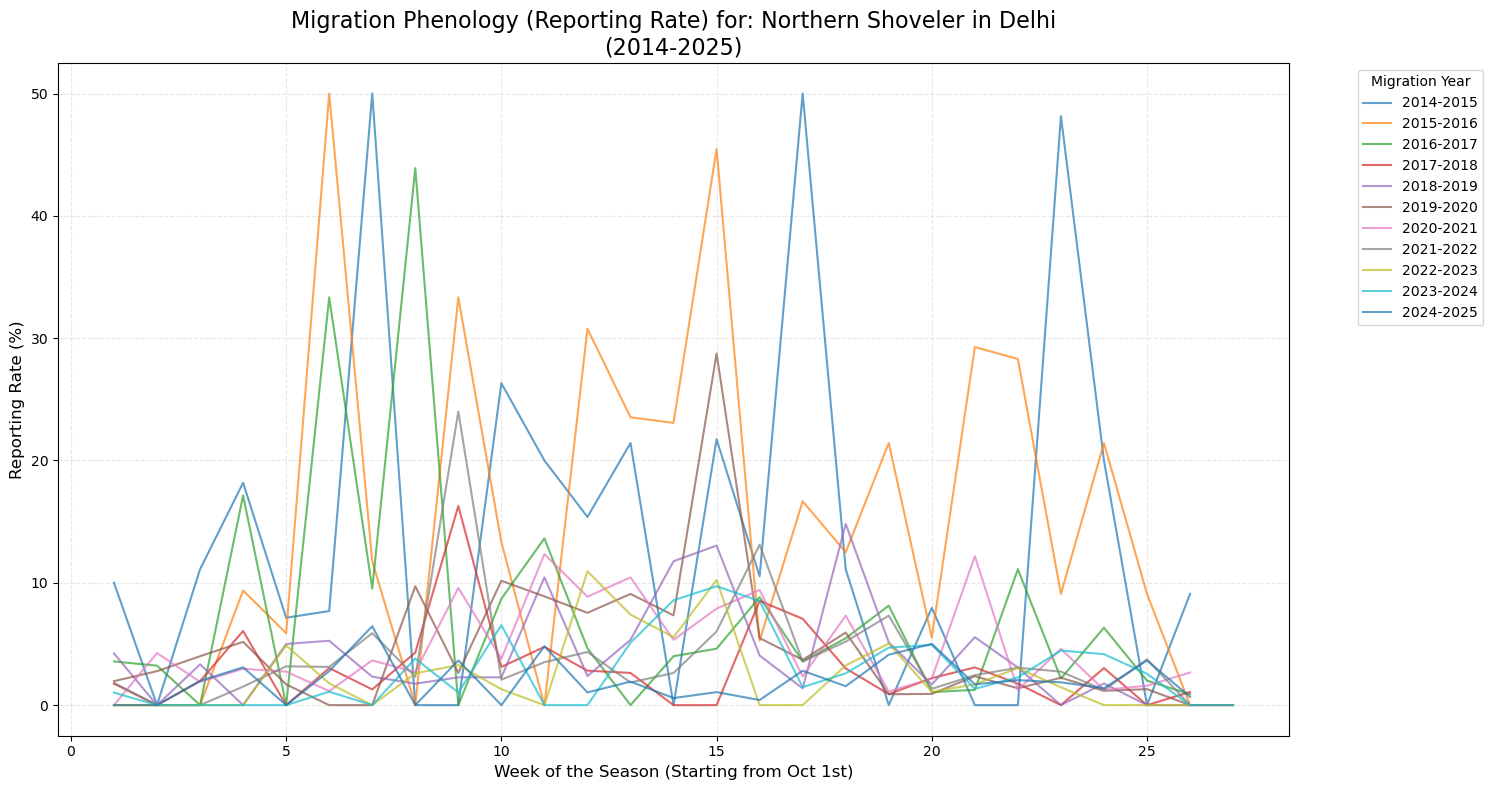

In [ ]:
TARGET_SPECIES = "Northern Shoveler"
print(f"Analyzing migration for: {TARGET_SPECIES}")

# --- 3. Calculate Reporting Rate (The Unbiased Metric) ---

# Check if SEASON_WEEK column exists
if 'SEASON_WEEK' not in df_clean.columns:
    print("\nError: The 'SEASON_WEEK' column was not found.")
    print("Please make sure you have run the LATEST version of the cleaning script ('clean_data_v3.py').")
    exit()

# Group by MIGRATION_YEAR and our new SEASON_WEEK
total_checklists = df_clean.groupby(['MIGRATION_YEAR', 'SEASON_WEEK'])['SAMPLING EVENT IDENTIFIER'].nunique()
df_species = df_clean[df_clean['COMMON NAME'] == TARGET_SPECIES]
species_checklists = df_species.groupby(['MIGRATION_YEAR', 'SEASON_WEEK'])['SAMPLING EVENT IDENTIFIER'].nunique()

# Calculate Reporting Rate
reporting_rate = (species_checklists / total_checklists) * 100
reporting_rate = reporting_rate.fillna(0)

# Re-format for plotting
try:
    plot_data = reporting_rate.unstack(level='MIGRATION_YEAR')
except KeyError:
    print(f"\nError: The species '{TARGET_SPECIES}' was not found in the dataset.")
    print("Please check the 'COMMON NAME' in your data and try again.")
    print("Tip: It must be an exact match (it is case-sensitive).")
    exit()
except Exception as e:
     print(f"An unexpected error occurred: {e}")
     exit()

# --- 4. Plot the Phenology Curves (NOW MUCH SIMPLER) ---
print("Plotting the data...")

plt.figure(figsize=(15, 8))
plt.title(f"Migration Phenology (Reporting Rate) for: {TARGET_SPECIES} in Delhi\n(2014-2025)", fontsize=16)

# The x-axis is now a simple continuous week number.
# No re-indexing needed!
for year in plot_data.columns:
    plt.plot(plot_data.index, plot_data[year], label=year, alpha=0.7)

# Make the plot beautiful
plt.xlabel("Week of the Season (Starting from Oct 1st)", fontsize=12) # <-- UPDATED LABEL
plt.ylabel("Reporting Rate (%)", fontsize=12)
plt.legend(title="Migration Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save the plot
output_filename = f"phenology_plot_{TARGET_SPECIES.replace(' ', '_')}.png"
plt.savefig(output_filename)

print(f"\n--- All Done! ---")
print(f"Successfully saved plot as: {output_filename}")
print("Check your folder for the PNG image file.")

Analyzing migration for: Black Kite
Plotting the data...

--- All Done! ---
Successfully saved plot as: phenology_plot_Black_Kite.png
Check your folder for the PNG image file.


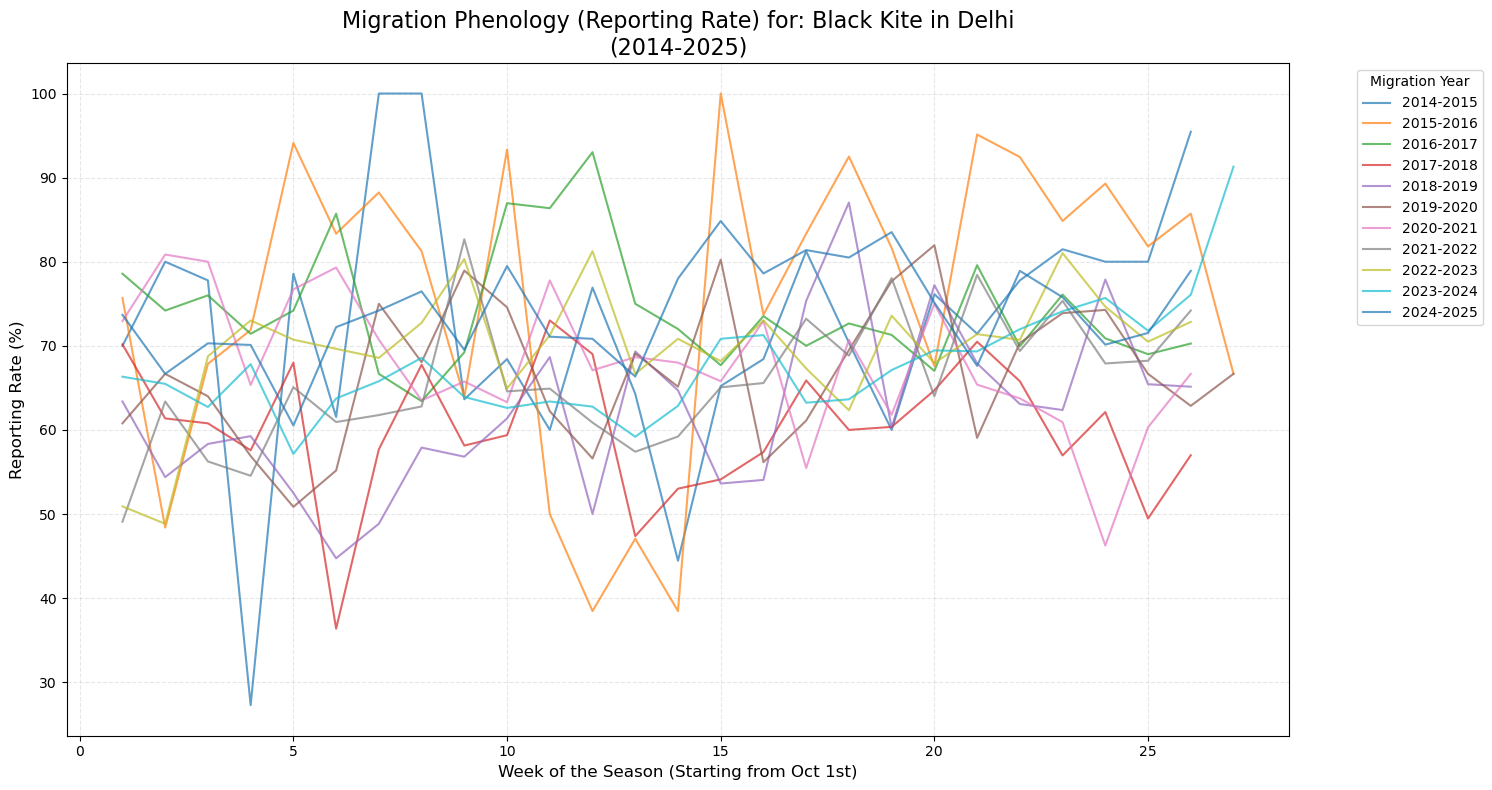

In [ ]:
TARGET_SPECIES = "Black Kite"
print(f"Analyzing migration for: {TARGET_SPECIES}")

# --- 3. Calculate Reporting Rate (The Unbiased Metric) ---

# Check if SEASON_WEEK column exists
if 'SEASON_WEEK' not in df_clean.columns:
    print("\nError: The 'SEASON_WEEK' column was not found.")
    print("Please make sure you have run the LATEST version of the cleaning script ('clean_data_v3.py').")
    exit()

# Group by MIGRATION_YEAR and our new SEASON_WEEK
total_checklists = df_clean.groupby(['MIGRATION_YEAR', 'SEASON_WEEK'])['SAMPLING EVENT IDENTIFIER'].nunique()
df_species = df_clean[df_clean['COMMON NAME'] == TARGET_SPECIES]
species_checklists = df_species.groupby(['MIGRATION_YEAR', 'SEASON_WEEK'])['SAMPLING EVENT IDENTIFIER'].nunique()

# Calculate Reporting Rate
reporting_rate = (species_checklists / total_checklists) * 100
reporting_rate = reporting_rate.fillna(0)

# Re-format for plotting
try:
    plot_data = reporting_rate.unstack(level='MIGRATION_YEAR')
except KeyError:
    print(f"\nError: The species '{TARGET_SPECIES}' was not found in the dataset.")
    print("Please check the 'COMMON NAME' in your data and try again.")
    print("Tip: It must be an exact match (it is case-sensitive).")
    exit()
except Exception as e:
     print(f"An unexpected error occurred: {e}")
     exit()

# --- 4. Plot the Phenology Curves (NOW MUCH SIMPLER) ---
print("Plotting the data...")

plt.figure(figsize=(15, 8))
plt.title(f"Migration Phenology (Reporting Rate) for: {TARGET_SPECIES} in Delhi\n(2014-2025)", fontsize=16)

# The x-axis is now a simple continuous week number.
# No re-indexing needed!
for year in plot_data.columns:
    plt.plot(plot_data.index, plot_data[year], label=year, alpha=0.7)

# Make the plot beautiful
plt.xlabel("Week of the Season (Starting from Oct 1st)", fontsize=12) # <-- UPDATED LABEL
plt.ylabel("Reporting Rate (%)", fontsize=12)
plt.legend(title="Migration Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save the plot
output_filename = f"phenology_plot_{TARGET_SPECIES.replace(' ', '_')}.png"
plt.savefig(output_filename)

print(f"\n--- All Done! ---")
print(f"Successfully saved plot as: {output_filename}")
print("Check your folder for the PNG image file.")

In [ ]:
if not pd.api.types.is_datetime64_any_dtype(df_clean['OBSERVATION DATE']):
    df_clean['OBSERVATION DATE'] = pd.to_datetime(df_clean['OBSERVATION DATE'])

print("Creating 'DAY_OF_SEASON'...")

start_year = df_clean['MIGRATION_YEAR'].str.slice(0, 4).astype(int)

season_start_date = pd.to_datetime(start_year.astype(str) + '-10-01')

time_delta = df_clean['OBSERVATION DATE'] - season_start_date

df_clean['DAY_OF_SEASON'] = time_delta.dt.days + 1

print("Successfully created 'DAY_OF_SEASON'.")

cols_to_drop = [
    'SCIENTIFIC NAME',
    'OBSERVATION DATE',
    'TIME OBSERVATIONS STARTED',
    'WEEK_OF_YEAR',
    'DAY_OF_YEAR'
]

existing_cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]

print(f"Dropping redundant columns: {existing_cols_to_drop}")
df_clean = df_clean.drop(columns=existing_cols_to_drop)

print("\nFinal Columns:")
print(df_clean.columns.to_list())

print("\nSample data for new 'DAY_OF_SEASON' feature:")
print(df_clean[['MIGRATION_YEAR', 'SEASON_WEEK', 'DAY_OF_SEASON']].sample(5))

Creating 'DAY_OF_SEASON'...
Successfully created 'DAY_OF_SEASON'.
Dropping redundant columns: ['SCIENTIFIC NAME', 'OBSERVATION DATE', 'TIME OBSERVATIONS STARTED', 'WEEK_OF_YEAR', 'DAY_OF_YEAR']

Final Columns:
['SAMPLING EVENT IDENTIFIER', 'MIGRATION_YEAR', 'COMMON NAME', 'OBSERVATION COUNT', 'PROTOCOL NAME', 'LATITUDE', 'LONGITUDE', 'DURATION MINUTES', 'EFFORT DISTANCE KM', 'NUMBER OBSERVERS', 'TIME_OF_DAY', 'SEASON_WEEK', 'TEMP_MAX', 'TEMP_MIN', 'PRECIPITATION', 'WIND_SPEED', 'PM10', 'PM2_5', 'AQI', 'DAY_OF_SEASON']

Sample data for new 'DAY_OF_SEASON' feature:
       MIGRATION_YEAR  SEASON_WEEK  DAY_OF_SEASON
395561      2024-2025           21            141
310275      2023-2024           12             84
148376      2018-2019           23            155
302000      2023-2024            3             18
64958       2016-2017           22            150


In [ ]:
df = df_clean

df_checklists = df.drop_duplicates(subset='SAMPLING EVENT IDENTIFIER')
print(f"Total bird observations (rows): {len(df)}")
print(f"Total unique checklists (samples): {len(df_checklists)}")

Total bird observations (rows): 418601
Total unique checklists (samples): 25888



Plotting: Top 20 Most Observed Species...


C:\Users\MSI-1\AppData\Local\Temp\ipykernel_34156\2338904092.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_species.values, y=top_20_species.index, palette='viridis')


Saved 'eda_top_20_species.png'.


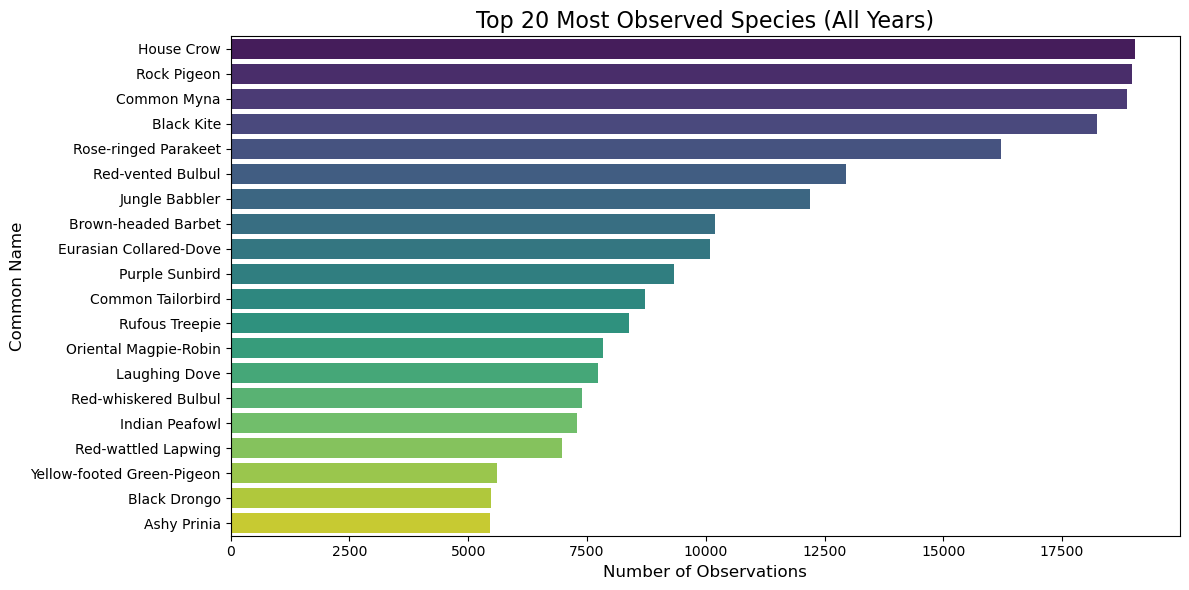

In [ ]:
print("\nPlotting: Top 20 Most Observed Species...")
plt.figure(figsize=(12, 6))
# We use the full 'df' here, as we are counting species observations
top_20_species = df['COMMON NAME'].value_counts().head(20)
sns.barplot(x=top_20_species.values, y=top_20_species.index, palette='viridis')
plt.title('Top 20 Most Observed Species (All Years)', fontsize=16)
plt.xlabel('Number of Observations', fontsize=12)
plt.ylabel('Common Name', fontsize=12)
plt.tight_layout()
plt.savefig('eda_top_20_species.png')
print("Saved 'eda_top_20_species.png'.")

Plotting: Observer Effort Over Time...
Saved 'eda_effort_over_time.png'.


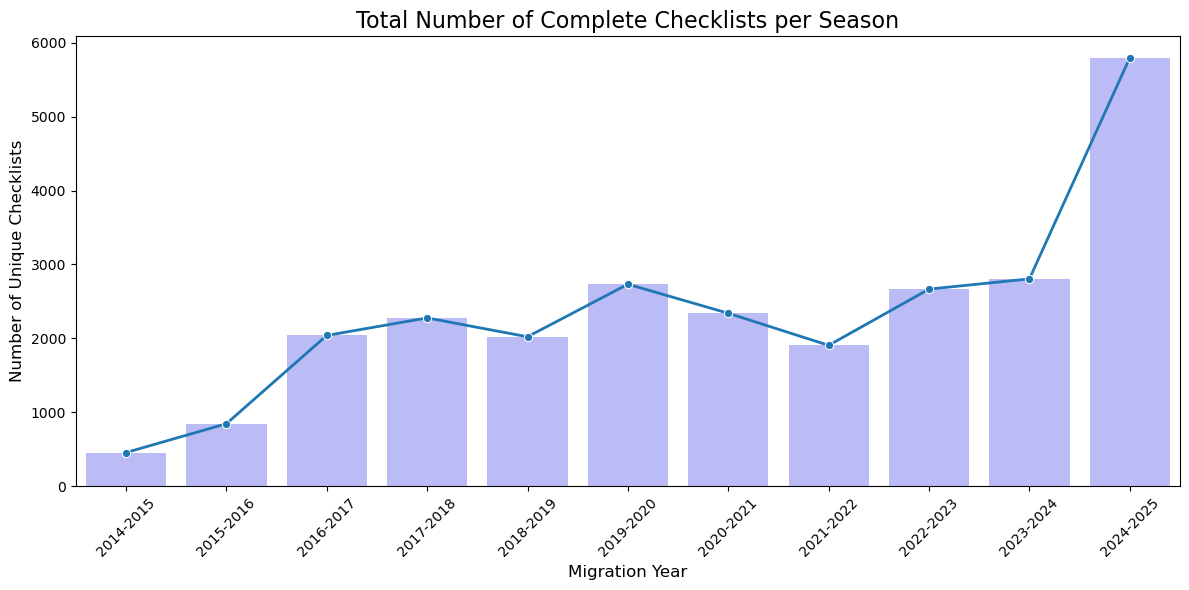

In [ ]:
print("Plotting: Observer Effort Over Time...")
plt.figure(figsize=(12, 6))
# We use 'df_checklists' here
effort_over_time = df_checklists['MIGRATION_YEAR'].value_counts().sort_index()
sns.lineplot(x=effort_over_time.index, y=effort_over_time.values, marker='o', lw=2)
sns.barplot(x=effort_over_time.index, y=effort_over_time.values, alpha=0.3, color='blue')
plt.title('Total Number of Complete Checklists per Season', fontsize=16)
plt.xlabel('Migration Year', fontsize=12)
plt.ylabel('Number of Unique Checklists', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_effort_over_time.png')
print("Saved 'eda_effort_over_time.png'.")

Plotting: Duration vs. Protocol...
Saved 'eda_duration_vs_protocol.png'.


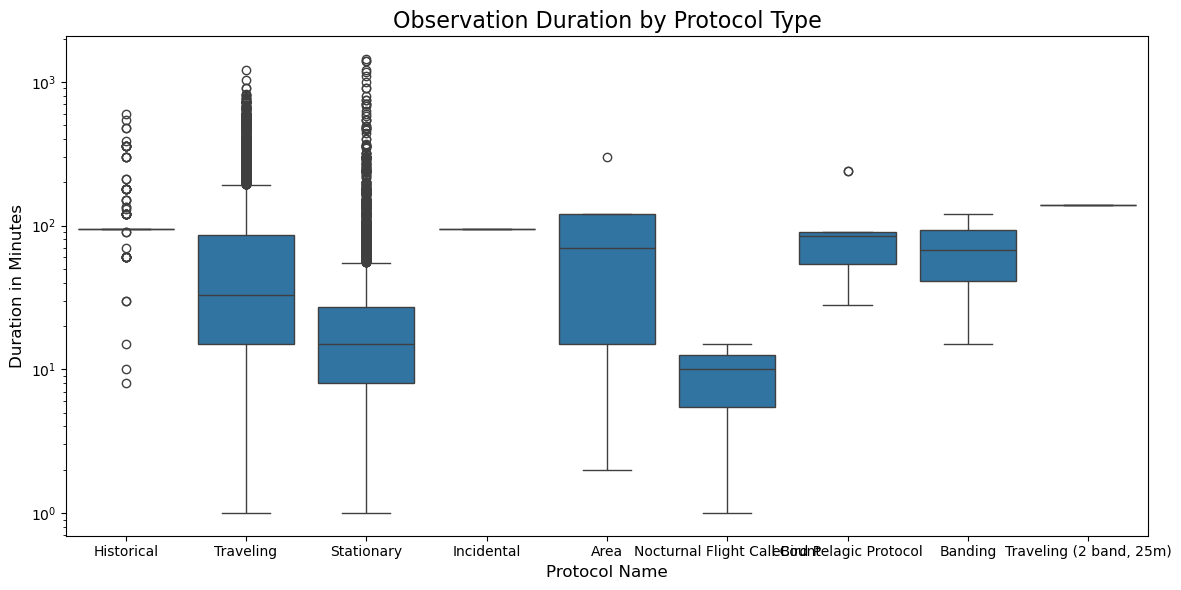

In [ ]:
print("Plotting: Duration vs. Protocol...")
plt.figure(figsize=(12, 6))
# We use 'df_checklists' and log-scale the duration
sns.boxplot(data=df_checklists, x='PROTOCOL NAME', y='DURATION MINUTES')
plt.title('Observation Duration by Protocol Type', fontsize=16)
plt.xlabel('Protocol Name', fontsize=12)
plt.ylabel('Duration in Minutes', fontsize=12)
plt.yscale('log') # Use log scale as duration is highly skewed
plt.tight_layout()
plt.savefig('eda_duration_vs_protocol.png')
print("Saved 'eda_duration_vs_protocol.png'.")

Plotting: Spatial Distribution of Checklists...
Saved 'eda_spatial_distribution.png'.


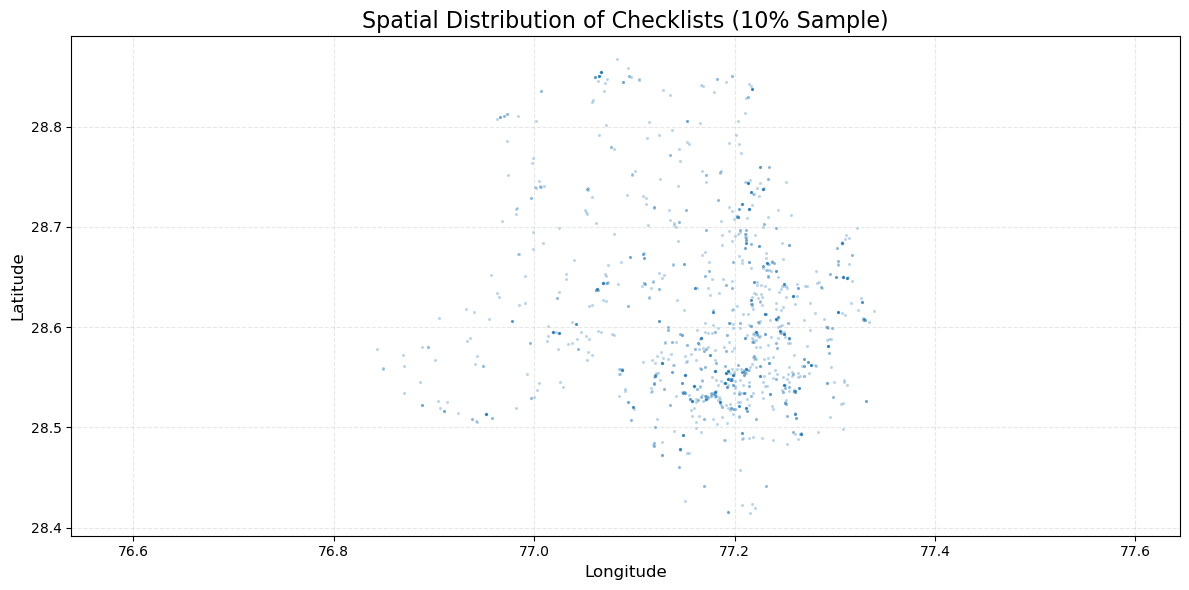

In [ ]:
print("Plotting: Spatial Distribution of Checklists...")
plt.figure(figsize=(12, 6))
# We use 'df_checklists' and a sample to plot faster
sns.scatterplot(data=df_checklists.sample(frac=0.1), # Plot 10% of points
                x='LONGITUDE', y='LATITUDE',
                s=5, alpha=0.3) # s=size, alpha=transparency
plt.title('Spatial Distribution of Checklists (10% Sample)', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal') # Make the plot aspect ratio equal
plt.tight_layout()
plt.savefig('eda_spatial_distribution.png')
print("Saved 'eda_spatial_distribution.png'.")

In [ ]:
df_clean

,SAMPLING EVENT IDENTIFIER,MIGRATION_YEAR,COMMON NAME,OBSERVATION COUNT,PROTOCOL NAME,LATITUDE,LONGITUDE,DURATION MINUTES,EFFORT DISTANCE KM,NUMBER OBSERVERS,TIME_OF_DAY,SEASON_WEEK,TEMP_MAX,TEMP_MIN,PRECIPITATION,WIND_SPEED,PM10,PM2_5,AQI,DAY_OF_SEASON
0,S96352034,2014-2015,Indian Pied Starling,1.0,Historical,28.671858,77.237242,93.938048,4.028308,3.27409,NaN,2,34.7,25.1,0.0,12.1,NaN,NaN,NaN,8
1,S100319446,2014-2015,Little Egret,1.0,Traveling,28.595167,77.221334,120.000000,2.000000,2.00000,Midday/Afternoon,2,34.5,21.0,0.0,11.0,NaN,NaN,NaN,11
2,S96352035,2014-2015,River Tern,1.0,Historical,28.671858,77.237242,93.938048,4.028308,3.27409,NaN,3,30.9,17.3,0.0,10.7,NaN,NaN,NaN,18
3,S21038397,2014-2015,Oriental Honey-buzzard,1.0,Traveling,28.535204,77.180757,180.000000,4.000000,2.00000,Morning,13,19.7,8.2,0.0,13.8,NaN,NaN,NaN,88
4,S20818360,2014-2015,Green Sandpiper,1.0,Traveling,28.696987,77.239680,240.000000,4.000000,7.00000,Morning,10,26.1,13.3,0.0,16.6,NaN,NaN,NaN,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418596,S221787904,2024-2025,Yellow-footed Green-Pigeon,2.0,Stationary,28.643769,77.069175,15.000000,4.028308,1.00000,Morning,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,177
418597,S216527138,2024-2025,Yellow-footed Green-Pigeon,4.0,Stationary,28.644360,77.071654,30.000000,4.028308,1.00000,Morning,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,155
418598,S221789176,2024-2025,Yellow-footed Green-Pigeon,1.0,Stationary,28.643769,77.069175,20.000000,4.028308,1.00000,Morning,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178
418599,S217840541,2024-2025,Yellow-footed Green-Pigeon,1.0,Stationary,28.643769,77.069175,20.000000,4.028308,1.00000,Evening,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,159


In [ ]:
df_clean.columns

Index(['SAMPLING EVENT IDENTIFIER', 'MIGRATION_YEAR', 'COMMON NAME',
       'OBSERVATION COUNT', 'PROTOCOL NAME', 'LATITUDE', 'LONGITUDE',
       'DURATION MINUTES', 'EFFORT DISTANCE KM', 'NUMBER OBSERVERS',
       'TIME_OF_DAY', 'SEASON_WEEK', 'TEMP_MAX', 'TEMP_MIN', 'PRECIPITATION',
       'WIND_SPEED', 'PM10', 'PM2_5', 'AQI', 'DAY_OF_SEASON'],
      dtype='object')

In [ ]:
# 1. Define features
env_features = ['TEMP_MAX', 'TEMP_MIN', 'PRECIPITATION', 'WIND_SPEED', 'PM10', 'PM2_5', 'AQI']
effort_features = ['DURATION MINUTES', 'EFFORT DISTANCE KM', 'NUMBER OBSERVERS', 'TIME_OF_DAY']
temporal_features = ['SEASON_WEEK', 'DAY_OF_SEASON']

# 2. Handle Missing Values (Crucial before PCA)
# Pollution data is likely missing for early years. We will fill with median for this example,
# but consider dropping early years if pollution analysis is critical.
imputer = SimpleImputer(strategy='median')
X_env = df_clean[env_features]
X_env_imputed = imputer.fit_transform(X_env)

# 3. Scale Data (PCA requires scaling)
scaler = StandardScaler()
X_env_scaled = scaler.fit_transform(X_env_imputed)

# 4. Apply PCA
# We want to keep enough components to explain 95% of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_env_scaled)

# Create a DataFrame for the PCA results
pca_cols = [f'PC_{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=df_clean.index)

# Join PCA results back to main dataframe
df_final = pd.concat([df_clean, df_pca], axis=1)

print(f"PCA reduced {len(env_features)} features to {len(pca_cols)} components.")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

# Interpret the Components (Optional but recommended)
loadings = pd.DataFrame(pca.components_.T, columns=pca_cols, index=env_features)
print("\nPCA Loadings (What does each component represent?):")
print(loadings)

PCA reduced 7 features to 4 components.
Explained Variance Ratio: [0.42156115 0.26812742 0.16631471 0.10714366]

PCA Loadings (What does each component represent?):
                   PC_1      PC_2      PC_3      PC_4
TEMP_MAX      -0.147852  0.682100 -0.134107 -0.044274
TEMP_MIN      -0.150874  0.683425  0.039989 -0.137096
PRECIPITATION -0.038920 -0.032574  0.789710 -0.595385
WIND_SPEED    -0.217537  0.093164  0.577790  0.778996
PM10           0.533889  0.175805  0.094853  0.106967
PM2_5          0.563709  0.107087  0.070946  0.043889
AQI            0.551120  0.124716  0.094349  0.067515


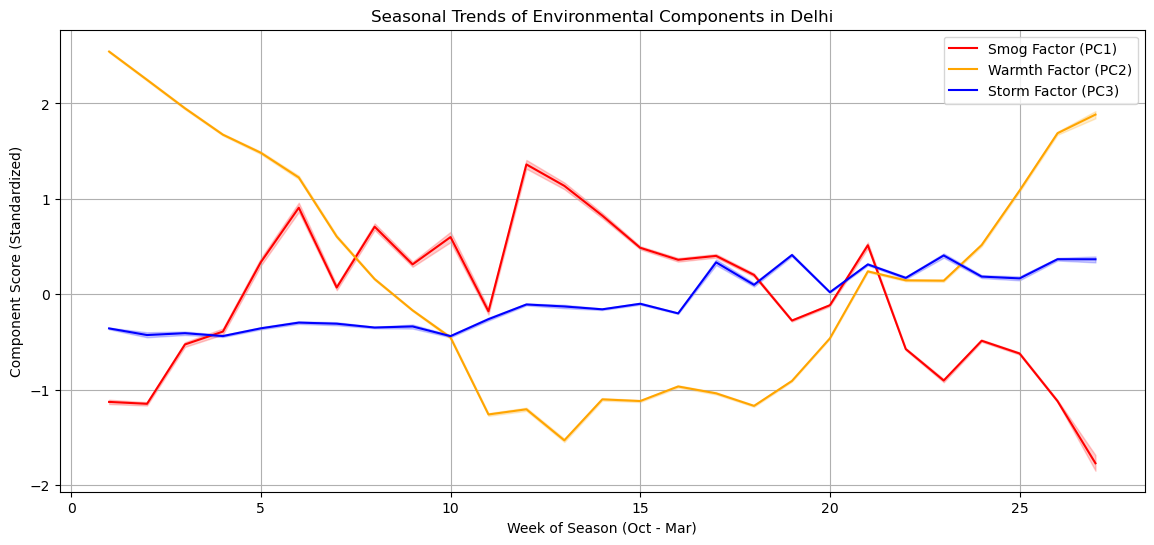

In [ ]:
# 1. Add PCA columns to your dataframe (assuming you ran the PCA code previously)
# Ensure df_final has 'PC_1', 'PC_2', 'PC_3', 'SEASON_WEEK'

# 2. Plot the Environmental Factors over the Season
plt.figure(figsize=(14, 6))

# Plot Smog Factor (PC1)
sns.lineplot(data=df_final, x='SEASON_WEEK', y='PC_1', label='Smog Factor (PC1)', color='red')

# Plot Warmth Factor (PC2)
sns.lineplot(data=df_final, x='SEASON_WEEK', y='PC_2', label='Warmth Factor (PC2)', color='orange')

# Plot Storm Factor (PC3)
sns.lineplot(data=df_final, x='SEASON_WEEK', y='PC_3', label='Storm Factor (PC3)', color='blue')

plt.title("Seasonal Trends of Environmental Components in Delhi")
plt.xlabel("Week of Season (Oct - Mar)")
plt.ylabel("Component Score (Standardized)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ==========================================
# STEP 1: PREPARE DATA & PCA (Feature Engineering)
# ==========================================
print("--- Step 1: Generating Environmental Indices (PCA) ---")

# 1. Select Features for PCA
env_features = ['TEMP_MAX', 'TEMP_MIN', 'PRECIPITATION', 'WIND_SPEED', 'PM10', 'PM2_5', 'AQI']

# 2. Handle Missing Values & Scale
# We use median imputation to handle any remaining gaps in pollution/weather data
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_env = df_clean[env_features]
X_env_imputed = imputer.fit_transform(X_env)
X_env_scaled = scaler.fit_transform(X_env_imputed)

# 3. Run PCA
pca = PCA(n_components=0.95) # Keep 95% of variance
X_pca = pca.fit_transform(X_env_scaled)

# 4. Create df_final
pca_cols = [f'PC_{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=df_clean.index)
df_final = pd.concat([df_clean, df_pca], axis=1)

print(f"PCA complete. Created {len(pca_cols)} components.")
print(f"Dataframe ready: {df_final.shape}")

--- Step 1: Generating Environmental Indices (PCA) ---
PCA complete. Created 4 components.
Dataframe ready: (418601, 24)


In [ ]:
# ==========================================
# STEP 2: DEFINE THE MODEL ARENA FUNCTION
# ==========================================
def run_model_arena(df, target_bird, feature_cols):
    """
    Trains multiple models with and without SMOTE and returns a performance dataframe.
    """
    print(f"\n--- Training Models for: {target_bird} ---")

    # 1. Prepare Data for the Specific Bird
    # Identify checklists where bird is present
    sightings = df[df['COMMON NAME'] == target_bird]['SAMPLING EVENT IDENTIFIER'].unique()

    # Aggregate to checklist level (One row per checklist)
    checklist_data = df[['SAMPLING EVENT IDENTIFIER'] + feature_cols].drop_duplicates()

    # Create Target (1 = Seen, 0 = Not Seen)
    checklist_data['TARGET'] = checklist_data['SAMPLING EVENT IDENTIFIER'].isin(sightings).astype(int)

    # Handle Time of Day (One-Hot Encoding)
    if 'TIME_OF_DAY' in checklist_data.columns:
        checklist_data = pd.get_dummies(checklist_data, columns=['TIME_OF_DAY'], drop_first=True)

    # Drop ID to get final Feature Matrix
    checklist_data = checklist_data.drop(columns=['SAMPLING EVENT IDENTIFIER'])

    X = checklist_data.drop(columns=['TARGET'])
    y = checklist_data['TARGET']

    print(f"Data Shape: {X.shape}")
    print(f"Class Balance: {y.mean()*100:.2f}% Positive Cases")

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Define Models to Test
    models = {
        'LogReg': LogisticRegression(max_iter=1000),
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        'GradientBoosting': GradientBoostingClassifier(random_state=42)
    }

    results = []

    # 2. Run Comparison Loop
    for name, model in models.items():
        # --- Scenario A: No SMOTE (Use Class Weights instead) ---
        if name in ['RandomForest', 'LogReg']:
            model.set_params(class_weight='balanced')

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

        # Metrics
        roc_auc = roc_auc_score(y_test, y_prob)
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall, precision)

        results.append({
            'Model': name,
            'Technique': 'Class Weighting (No SMOTE)',
            'ROC_AUC': roc_auc,
            'PR_AUC': pr_auc
        })

        # --- Scenario B: With SMOTE ---
        sm = SMOTE(random_state=42)
        X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

        # Reset class_weight for SMOTE (data is now balanced)
        if name in ['RandomForest', 'LogReg']:
            model.set_params(class_weight=None)

        model.fit(X_train_sm, y_train_sm)
        y_prob_sm = model.predict_proba(X_test)[:, 1]

        # Metrics
        roc_auc_sm = roc_auc_score(y_test, y_prob_sm)
        precision_sm, recall_sm, _ = precision_recall_curve(y_test, y_prob_sm)
        pr_auc_sm = auc(recall_sm, precision_sm)

        results.append({
            'Model': name,
            'Technique': 'SMOTE Oversampling',
            'ROC_AUC': roc_auc_sm,
            'PR_AUC': pr_auc_sm
        })

    # 3. Format Output
    results_df = pd.DataFrame(results).sort_values(by='PR_AUC', ascending=False)
    return results_df, checklist_data


--- Training Models for: Northern Shoveler ---
Data Shape: (25888, 12)
Class Balance: 3.92% Positive Cases


C:\Users\MSI-1\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Final Leaderboard ---
              Model                   Technique   ROC_AUC    PR_AUC
2      RandomForest  Class Weighting (No SMOTE)  0.969201  0.774526
3      RandomForest          SMOTE Oversampling  0.944303  0.689568
4  GradientBoosting  Class Weighting (No SMOTE)  0.946833  0.618435
5  GradientBoosting          SMOTE Oversampling  0.917648  0.514544
0            LogReg  Class Weighting (No SMOTE)  0.845105  0.214782
1            LogReg          SMOTE Oversampling  0.810038  0.204822


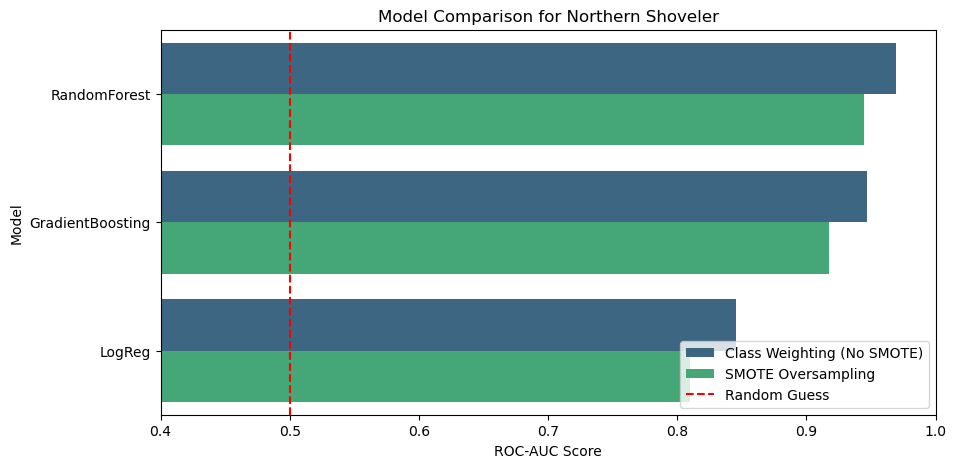

In [ ]:
# ==========================================
# STEP 3: EXECUTE THE COMPARISON
# ==========================================

# Define the features we want to use for prediction
# (Includes our new PCA components + Effort variables)
features_to_use = list(pca_cols) + ['SEASON_WEEK', 'LATITUDE', 'LONGITUDE',
                                    'DURATION MINUTES', 'EFFORT DISTANCE KM', 'TIME_OF_DAY']

# Choose your bird!
target_bird = "Northern Shoveler"

# Run the Arena
comparison_results, final_dataset = run_model_arena(df_final, target_bird, features_to_use)

# Display Results
print("\n--- Final Leaderboard ---")
print(comparison_results)

# Plot the Leaderboard
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_results, x='ROC_AUC', y='Model', hue='Technique', palette='viridis')
plt.title(f"Model Comparison for {target_bird}")
plt.xlabel("ROC-AUC Score")
plt.axvline(0.5, color='red', linestyle='--', label='Random Guess')
plt.xlim(0.4, 1.0)
plt.legend(loc='lower right')
plt.show()

📊 DETAILED REPORT FOR: NORTHERN SHOVELER

🔹 MODEL: Logistic Regression
----------------------------------------
              precision    recall  f1-score   support

      Absent       0.99      0.83      0.90      4975
     Present       0.15      0.71      0.24       203

    accuracy                           0.83      5178
   macro avg       0.57      0.77      0.57      5178
weighted avg       0.95      0.83      0.88      5178



C:\Users\MSI-1\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


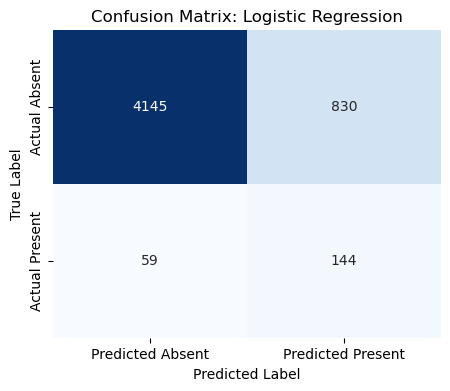



🔹 MODEL: Logistic Regression (SMOTE)
----------------------------------------
              precision    recall  f1-score   support

      Absent       0.98      0.88      0.93      4975
     Present       0.18      0.61      0.27       203

    accuracy                           0.87      5178
   macro avg       0.58      0.75      0.60      5178
weighted avg       0.95      0.87      0.90      5178



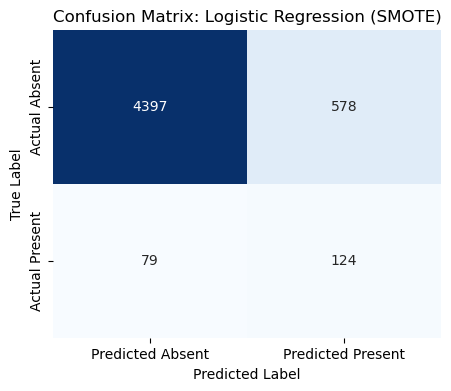



🔹 MODEL: Random Forest
----------------------------------------
              precision    recall  f1-score   support

      Absent       0.98      1.00      0.99      4975
     Present       0.86      0.55      0.67       203

    accuracy                           0.98      5178
   macro avg       0.92      0.77      0.83      5178
weighted avg       0.98      0.98      0.98      5178



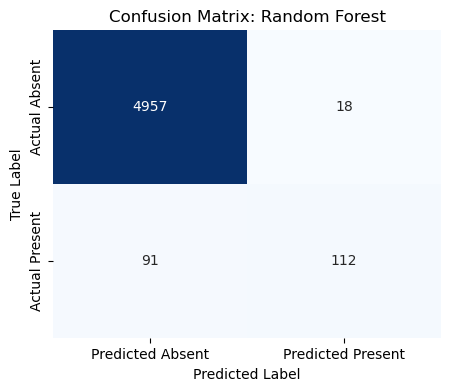



🔹 MODEL: Random Forest (SMOTE)
----------------------------------------
              precision    recall  f1-score   support

      Absent       0.99      0.98      0.98      4975
     Present       0.59      0.64      0.61       203

    accuracy                           0.97      5178
   macro avg       0.79      0.81      0.80      5178
weighted avg       0.97      0.97      0.97      5178



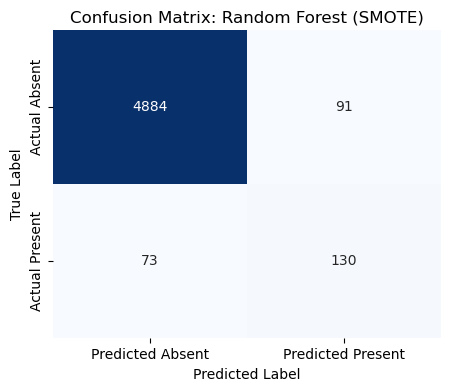



🔹 MODEL: Gradient Boosting
----------------------------------------
              precision    recall  f1-score   support

      Absent       0.97      1.00      0.99      4975
     Present       0.80      0.34      0.48       203

    accuracy                           0.97      5178
   macro avg       0.89      0.67      0.73      5178
weighted avg       0.97      0.97      0.97      5178



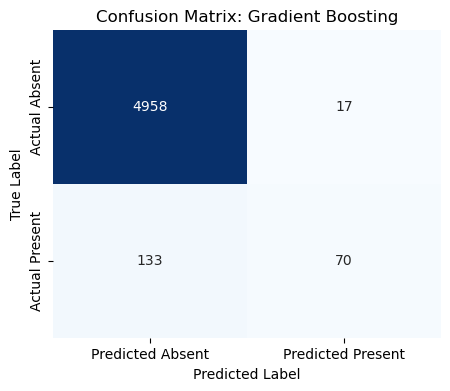



🔹 MODEL: Gradient Boosting (SMOTE)
----------------------------------------
              precision    recall  f1-score   support

      Absent       0.99      0.89      0.94      4975
     Present       0.23      0.79      0.35       203

    accuracy                           0.89      5178
   macro avg       0.61      0.84      0.64      5178
weighted avg       0.96      0.89      0.91      5178



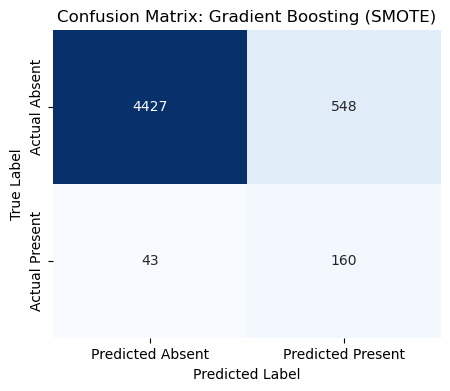

In [ ]:
def evaluate_models_detailed(df, target_bird, feature_cols):
    print(f"📊 DETAILED REPORT FOR: {target_bird.upper()}\n" + "="*60)

    # --- 1. Data Prep (Same as before) ---
    sightings = df[df['COMMON NAME'] == target_bird]['SAMPLING EVENT IDENTIFIER'].unique()
    checklist_data = df[['SAMPLING EVENT IDENTIFIER'] + feature_cols].drop_duplicates()
    checklist_data['TARGET'] = checklist_data['SAMPLING EVENT IDENTIFIER'].isin(sightings).astype(int)

    if 'TIME_OF_DAY' in checklist_data.columns:
        checklist_data = pd.get_dummies(checklist_data, columns=['TIME_OF_DAY'], drop_first=True)

    X = checklist_data.drop(columns=['SAMPLING EVENT IDENTIFIER', 'TARGET'])
    y = checklist_data['TARGET']

    # Stratified Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # --- 2. Define The 6 Configurations ---
    # (Model Name, Model Object, Use SMOTE?)
    configs = [
        ("Logistic Regression", LogisticRegression(max_iter=1000, class_weight='balanced'), False),
        ("Logistic Regression (SMOTE)", LogisticRegression(max_iter=1000), True),

        ("Random Forest", RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42), False),
        ("Random Forest (SMOTE)", RandomForestClassifier(n_estimators=100, random_state=42), True),

        ("Gradient Boosting", GradientBoostingClassifier(random_state=42), False), # GBM doesn't support class_weight='balanced' natively in older sklearn, but we test as is
        ("Gradient Boosting (SMOTE)", GradientBoostingClassifier(random_state=42), True)
    ]

    # --- 3. Run & Visualize ---
    for model_name, model, use_smote in configs:
        print(f"\n🔹 MODEL: {model_name}")
        print("-" * 40)

        # Training Logic
        if use_smote:
            sm = SMOTE(random_state=42)
            X_train_run, y_train_run = sm.fit_resample(X_train, y_train)
        else:
            X_train_run, y_train_run = X_train, y_train

        model.fit(X_train_run, y_train_run)
        y_pred = model.predict(X_test)

        # A. Classification Report
        # We explicitly print labels for 0 (Absent) and 1 (Present)
        print(classification_report(y_test, y_pred, target_names=['Absent', 'Present']))

        # B. Confusion Matrix Plot
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Predicted Absent', 'Predicted Present'],
                    yticklabels=['Actual Absent', 'Actual Present'])
        plt.title(f"Confusion Matrix: {model_name}")
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
        print("\n" + "="*60)

# --- EXECUTION ---
# Ensure 'features_to_use' is defined (from previous step)
evaluate_models_detailed(df_final, "Northern Shoveler", features_to_use)

--- Re-building Data for Northern Shoveler ---
Training Random Forest (Weighted)...

--- Threshold Optimization Results ---
Default Threshold (0.50) F1: 0.671
Optimal Threshold:       0.310
Optimized F1 Score:      0.681


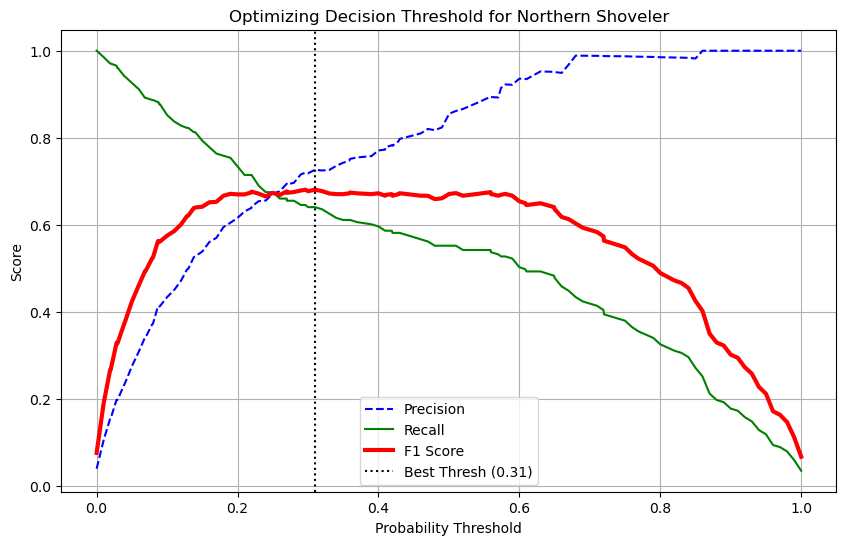


--- Final Classification Report (Threshold = 0.310) ---
              precision    recall  f1-score   support

      Absent       0.99      0.99      0.99      4975
     Present       0.73      0.64      0.68       203

    accuracy                           0.98      5178
   macro avg       0.86      0.82      0.83      5178
weighted avg       0.98      0.98      0.98      5178



In [ ]:
# --- 1. RE-PREPARE THE DATA (Global Scope) ---
target_bird = "Northern Shoveler"

# Define features (Same as before)
features_to_use = [col for col in df_final.columns if col.startswith('PC_')] + \
                  ['SEASON_WEEK', 'LATITUDE', 'LONGITUDE',
                   'DURATION MINUTES', 'EFFORT DISTANCE KM', 'TIME_OF_DAY']

print(f"--- Re-building Data for {target_bird} ---")

# Identify sightings
sightings = df_final[df_final['COMMON NAME'] == target_bird]['SAMPLING EVENT IDENTIFIER'].unique()

# Create checklist-level dataset
checklist_data = df_final[['SAMPLING EVENT IDENTIFIER'] + features_to_use].drop_duplicates()
checklist_data['TARGET'] = checklist_data['SAMPLING EVENT IDENTIFIER'].isin(sightings).astype(int)

# Handle Time of Day
if 'TIME_OF_DAY' in checklist_data.columns:
    checklist_data = pd.get_dummies(checklist_data, columns=['TIME_OF_DAY'], drop_first=True)

# Create X and y
X = checklist_data.drop(columns=['SAMPLING EVENT IDENTIFIER', 'TARGET'])
y = checklist_data['TARGET']

# Split (Now these variables exist globally!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 2. TRAIN THE CHAMPION MODEL ---
print("Training Random Forest (Weighted)...")
rf_best = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_best.fit(X_train, y_train)


# --- 3. OPTIMIZE THRESHOLD FUNCTION ---
def optimize_threshold(model, X_test, y_test):
    # Get probabilities for the positive class (Present)
    y_probs = model.predict_proba(X_test)[:, 1]

    # Calculate precision-recall curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

    # Calculate F1 score for each threshold
    # Note: F1 = 2 * (P * R) / (P + R)
    with np.errstate(divide='ignore', invalid='ignore'):
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
    f1_scores = np.nan_to_num(f1_scores) # Handle NaNs

    # Find the index of the highest F1 score
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"\n--- Threshold Optimization Results ---")
    print(f"Default Threshold (0.50) F1: {f1_score(y_test, (y_probs >= 0.5).astype(int)):.3f}")
    print(f"Optimal Threshold:       {best_thresh:.3f}")
    print(f"Optimized F1 Score:      {best_f1:.3f}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    plt.plot(thresholds, f1_scores[:-1], 'r-', linewidth=3, label='F1 Score')
    plt.axvline(best_thresh, color='black', linestyle=':', label=f'Best Thresh ({best_thresh:.2f})')
    plt.title(f"Optimizing Decision Threshold for {target_bird}")
    plt.xlabel("Probability Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_thresh

# --- 4. EXECUTE OPTIMIZATION ---
best_thresh = optimize_threshold(rf_best, X_test, y_test)

# --- 5. FINAL REPORT ---
print(f"\n--- Final Classification Report (Threshold = {best_thresh:.3f}) ---")
y_probs_final = rf_best.predict_proba(X_test)[:, 1]
y_pred_optimized = (y_probs_final >= best_thresh).astype(int)

print(classification_report(y_test, y_pred_optimized, target_names=['Absent', 'Present']))

Calculating learning curve for: Learning Curve: Northern Shoveler (Random Forest)...


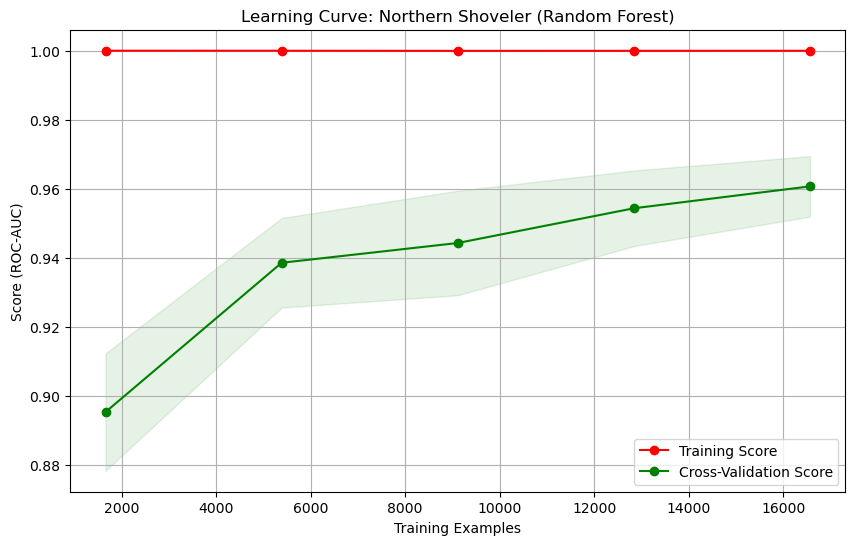

In [ ]:
def plot_learning_curve(estimator, X, y, title="Learning Curve"):
    """
    Plots the learning curve (Training vs Validation score) over increasing data sizes.
    """
    print(f"Calculating learning curve for: {title}...")

    # 1. Compute Learning Curve
    # cv=5 means 5-fold Cross-Validation
    # scoring='roc_auc' is used because it works regardless of your 0.310 threshold
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='roc_auc'
    )

    # 2. Calculate Means and Standard Deviations
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # 3. Plot
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training Examples")
    plt.ylabel("Score (ROC-AUC)")
    plt.grid()

    # Plot the filled area (Standard Deviation)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")

    # Plot the lines (Means)
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")

    plt.legend(loc="best")
    plt.show()

# --- EXECUTION ---
# We use the same 'rf_best' model and the full training set 'X_train'
plot_learning_curve(rf_best, X_train, y_train, title=f"Learning Curve: {target_bird} (Random Forest)")

--- Training Neural Network Challenger for Northern Shoveler ---


C:\Users\MSI-1\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.7327 - loss: 0.6124 - val_AUC: 0.8554 - val_loss: 0.5215 - learning_rate: 0.0010
Epoch 2/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8297 - loss: 0.5159 - val_AUC: 0.8718 - val_loss: 0.4749 - learning_rate: 0.0010
Epoch 3/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8468 - loss: 0.4891 - val_AUC: 0.8818 - val_loss: 0.4704 - learning_rate: 0.0010
Epoch 4/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8604 - loss: 0.4676 - val_AUC: 0.8836 - val_loss: 0.4782 - learning_rate: 0.0010
Epoch 5/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8620 - loss: 0.4646 - val_AUC: 0.8822 - val_loss: 0.4677 - learning_rate: 0.0010
Epoch 6/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8703 - loss: 0.4531 - val_AUC: 0.8925 - val_loss: 0.4155 - learning_rate: 0.0010
Epoch 7/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8757 - loss: 0.4440 - val_AUC: 0.8964 - val_loss: 0.4229 - learning_rate: 0.0010

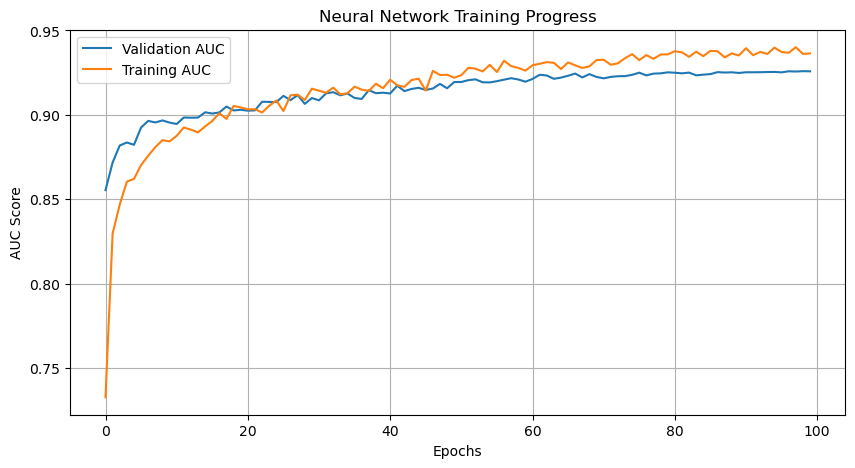

In [ ]:
print(f"--- Training Neural Network Challenger for {target_bird} ---")

# 1. Prepare Data (Neural Nets NEED Scaling)
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled = scaler_nn.transform(X_test)

# Calculate Class Weights
total = len(y_train)
pos = y_train.sum()
neg = total - pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight_dict = {0: weight_for_0, 1: weight_for_1}

# 2. Build the Architecture
model = Sequential([
    # Input Layer
    Dense(128, input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    # Hidden Layer 1
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(32),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.2),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# 3. Compile
# Note: We use metrics=['AUC']. Keras will name this 'AUC' and 'val_AUC'.
optimizer = Adam(learning_rate=0.001)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['AUC'])

# 4. Callbacks (FIXED HERE)
# changed 'val_auc' to 'val_AUC' and added mode='max'
early_stop = EarlyStopping(
    monitor='val_AUC',
    patience=15,
    mode='max',
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_AUC',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    mode='max'  # Explicitly tell it that higher is better
)

# 5. Train
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# 6. Evaluate
print("\n--- Neural Network Results ---")
y_pred_nn_prob = model.predict(X_test_scaled)

# Calculate Metrics
nn_auc = roc_auc_score(y_test, y_pred_nn_prob)
precision_nn, recall_nn, _ = precision_recall_curve(y_test, y_pred_nn_prob)
nn_pr_auc = auc(recall_nn, precision_nn)

print(f"Neural Net ROC-AUC: {nn_auc:.4f}")
print(f"Neural Net PR-AUC:  {nn_pr_auc:.4f}")
print(f"RF Baseline PR-AUC: 0.7745") # Compare this to your previous best

# Plot Training History
# Note: History keys are also case sensitive!
plt.figure(figsize=(10,5))
plt.plot(history.history['val_AUC'], label='Validation AUC')
plt.plot(history.history['AUC'], label='Training AUC')
plt.title('Neural Network Training Progress')
plt.xlabel('Epochs')
plt.ylabel('AUC Score')
plt.legend()
plt.grid(True)
plt.show()

--- Neural Network Detailed Evaluation ---
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Classification Report (Threshold = 0.5):
              precision    recall  f1-score   support

      Absent       0.99      0.85      0.91      4975
     Present       0.19      0.86      0.31       203

    accuracy                           0.85      5178
   macro avg       0.59      0.85      0.61      5178
weighted avg       0.96      0.85      0.89      5178



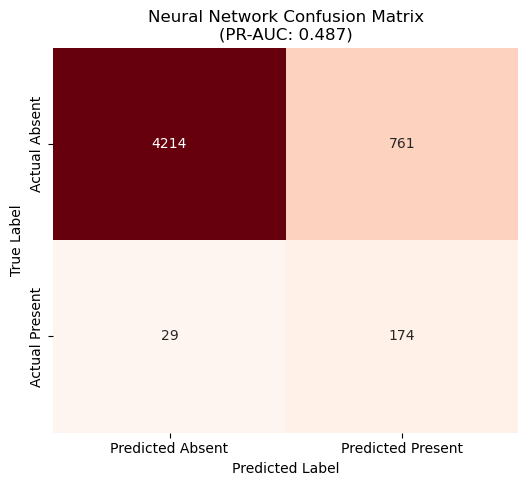

In [ ]:
print("--- Neural Network Detailed Evaluation ---")

# 1. Get Predictions
# Keras outputs probabilities (e.g., 0.78). We convert to 1 if > 0.5, else 0.
y_pred_nn_prob = model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)

# 2. Classification Report
print("\nClassification Report (Threshold = 0.5):")
print(classification_report(y_test, y_pred_nn, target_names=['Absent', 'Present']))

# 3. Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Predicted Absent', 'Predicted Present'],
            yticklabels=['Actual Absent', 'Actual Present'])
plt.title(f"Neural Network Confusion Matrix\n(PR-AUC: {nn_pr_auc:.3f})")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

--- Training Neural Network + SMOTE for Northern Shoveler ---
Original Class Balance: 3.93%
SMOTE Class Balance:    50.00%
Epoch 1/100


C:\Users\MSI-1\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


622/622 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.8897 - loss: 0.4175 - val_AUC: 0.8687 - val_loss: 0.2706 - learning_rate: 0.0010
Epoch 2/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.9316 - loss: 0.3332 - val_AUC: 0.8788 - val_loss: 0.2582 - learning_rate: 0.0010
Epoch 3/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.9412 - loss: 0.3103 - val_AUC: 0.8841 - val_loss: 0.2609 - learning_rate: 0.0010
Epoch 4/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.9461 - loss: 0.2963 - val_AUC: 0.8861 - val_loss: 0.2725 - learning_rate: 0.0010
Epoch 5/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.9495 - loss: 0.2871 - val_AUC: 0.8932 - val_loss: 0.2545 - learning_rate: 0.0010
Epoch 6/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.9530 - loss: 0.2772 - val_AUC: 0.8926 - val_loss: 0.2609 - learning_rate: 0.0010
Epoch 7/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.9540 - loss: 0.2739 - val_AUC: 0.8895 - val_loss: 0.2601 - learning_rate: 0.0010
Epoch 8/100

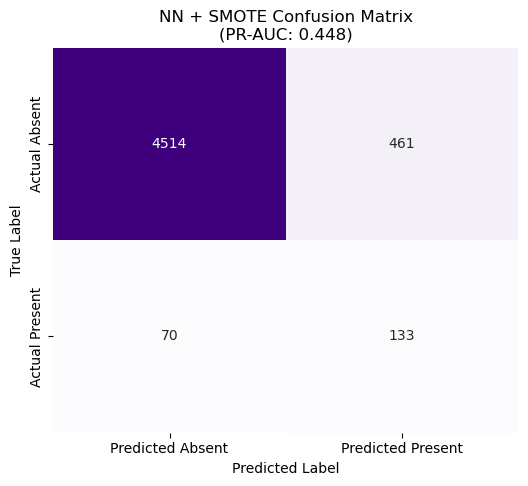

In [ ]:
print(f"--- Training Neural Network + SMOTE for {target_bird} ---")

# 1. Apply SMOTE to the Training Data (Raw)
# Note: We use the X_train/y_train from previous steps (before scaling)
print(f"Original Class Balance: {y_train.mean()*100:.2f}%")

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"SMOTE Class Balance:    {y_train_sm.mean()*100:.2f}%")

# 2. Scale the Data (Crucial for NN)
# We fit the scaler on the SMOTE-augmented training set
scaler_sm = StandardScaler()
X_train_sm_scaled = scaler_sm.fit_transform(X_train_sm)
X_test_scaled = scaler_sm.transform(X_test)

# 3. Build the Architecture (Same as before)
model_sm = Sequential([
    # Input Layer
    Dense(128, input_shape=(X_train_sm_scaled.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    # Hidden Layer 1
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(32),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.2),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# 4. Compile
# We do NOT use class_weight here because SMOTE has balanced the data
optimizer = Adam(learning_rate=0.001)
model_sm.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['AUC'])

# 5. Callbacks
early_stop = EarlyStopping(monitor='val_AUC', patience=15, mode='max', restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_AUC', factor=0.5, patience=5, min_lr=0.00001, mode='max')

# 6. Train
history_sm = model_sm.fit(
    X_train_sm_scaled, y_train_sm,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# 7. Evaluate
print("\n--- Neural Network + SMOTE Results ---")
y_pred_sm_prob = model_sm.predict(X_test_scaled)

# Metrics
auc_score = roc_auc_score(y_test, y_pred_sm_prob)
precision, recall, _ = precision_recall_curve(y_test, y_pred_sm_prob)
pr_auc_score = auc(recall, precision)

print(f"NN (SMOTE) ROC-AUC: {auc_score:.4f}")
print(f"NN (SMOTE) PR-AUC:  {pr_auc_score:.4f}")
print(f"vs RF (Weighted) PR-AUC: ~0.77")

# Classification Report (Threshold 0.5)
y_pred_sm = (y_pred_sm_prob > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sm, target_names=['Absent', 'Present']))

# Confusion Matrix
cm_sm = confusion_matrix(y_test, y_pred_sm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_sm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Predicted Absent', 'Predicted Present'],
            yticklabels=['Actual Absent', 'Actual Present'])
plt.title(f"NN + SMOTE Confusion Matrix\n(PR-AUC: {pr_auc_score:.3f})")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Generating Impact Scenarios for Northern Shoveler...
Simulating: Clean Air (PC1=-1.08) vs. Smog (PC1=0.53)


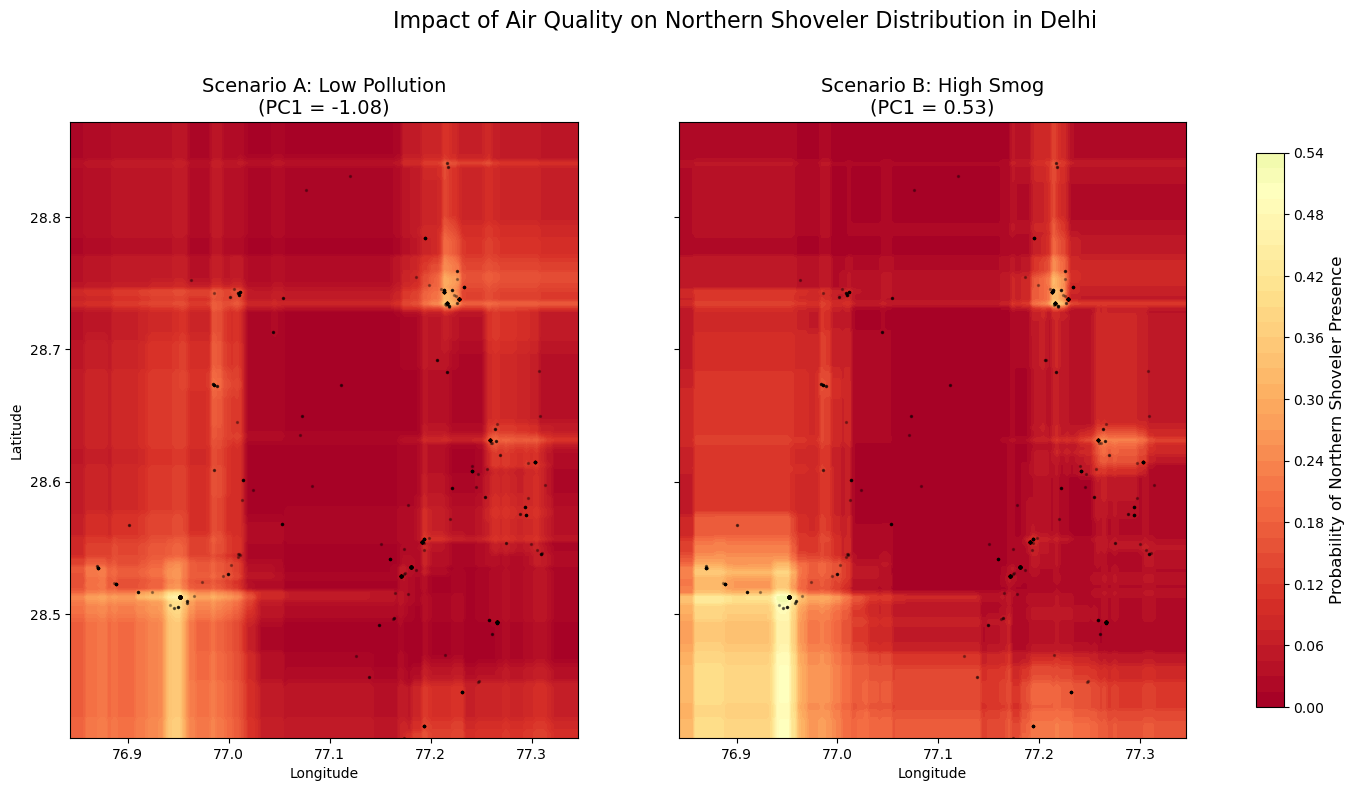

In [ ]:
def plot_pollution_impact_map(model, df, target_bird, grid_res=150):
    print(f"Generating Impact Scenarios for {target_bird}...")

    # 1. Create the Spatial Grid
    lat_min, lat_max = df['LATITUDE'].min(), df['LATITUDE'].max()
    lon_min, lon_max = df['LONGITUDE'].min(), df['LONGITUDE'].max()

    x_axis = np.linspace(lon_min, lon_max, grid_res)
    y_axis = np.linspace(lat_min, lat_max, grid_res)
    xv, yv = np.meshgrid(x_axis, y_axis)

    # Base Grid DataFrame
    grid_df = pd.DataFrame({
        'LONGITUDE': xv.ravel(),
        'LATITUDE': yv.ravel()
    })

    # 2. Define Scenarios
    # We need to know which PC represents Pollution.
    # Based on your earlier analysis, PC_1 was Pollution/Smog.
    # We will take the 10th percentile (Clean) and 90th percentile (Smog) of PC_1.

    clean_val = df['PC_1'].quantile(0.10)
    smog_val = df['PC_1'].quantile(0.90)

    print(f"Simulating: Clean Air (PC1={clean_val:.2f}) vs. Smog (PC1={smog_val:.2f})")

    # 3. Prepare Features (Set defaults for everything else)
    # We use the median for all other variables to isolate the Pollution effect.
    feature_cols = [col for col in model.feature_names_in_]

    for col in feature_cols:
        if col not in ['LATITUDE', 'LONGITUDE', 'PC_1']:
            if 'TIME_OF_DAY' in col:
                grid_df[col] = 0
            else:
                grid_df[col] = df[col].median()

    # Set specific context
    if 'TIME_OF_DAY_AM' in grid_df.columns:
        grid_df['TIME_OF_DAY_AM'] = 1  # Assume morning birding
    if 'SEASON_WEEK' in grid_df.columns:
        grid_df['SEASON_WEEK'] = 15     # Peak Winter (Jan)

    # --- SCENARIO 1: CLEAN AIR ---
    grid_df['PC_1'] = clean_val
    # Reorder columns to match model input
    X_clean = grid_df[feature_cols]
    probs_clean = model.predict_proba(X_clean)[:, 1].reshape(grid_res, grid_res)

    # --- SCENARIO 2: HIGH SMOG ---
    grid_df['PC_1'] = smog_val
    X_smog = grid_df[feature_cols]
    probs_smog = model.predict_proba(X_smog)[:, 1].reshape(grid_res, grid_res)

    # 4. Plotting Side-by-Side
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

    # Plot Clean
    im1 = axes[0].contourf(xv, yv, probs_clean, levels=50, cmap='RdYlGn', vmin=0, vmax=1)
    axes[0].set_title(f"Scenario A: Low Pollution\n(PC1 = {clean_val:.2f})", fontsize=14)
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")

    # Plot Smog
    im2 = axes[1].contourf(xv, yv, probs_smog, levels=50, cmap='RdYlGn', vmin=0, vmax=1)
    axes[1].set_title(f"Scenario B: High Smog\n(PC1 = {smog_val:.2f})", fontsize=14)
    axes[1].set_xlabel("Longitude")

    # Overlay Actual Sightings (for context)
    actual = df[df['COMMON NAME'] == target_bird]
    axes[0].scatter(actual['LONGITUDE'], actual['LATITUDE'], c='black', s=2, alpha=0.3, label='Known Sightings')
    axes[1].scatter(actual['LONGITUDE'], actual['LATITUDE'], c='black', s=2, alpha=0.3)

    # Colorbar
    cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.9)
    cbar.set_label(f"Probability of {target_bird} Presence", fontsize=12)

    plt.suptitle(f"Impact of Air Quality on {target_bird} Distribution in Delhi", fontsize=16, y=1.02)
    plt.show()

# --- EXECUTION ---
# Ensure rf_best is your Random Forest model
plot_pollution_impact_map(rf_best, df_final, "Northern Shoveler")

--- Running Sensitivity Control Experiment ---
Training model for: Northern Shoveler...
Training model for: Black Kite...


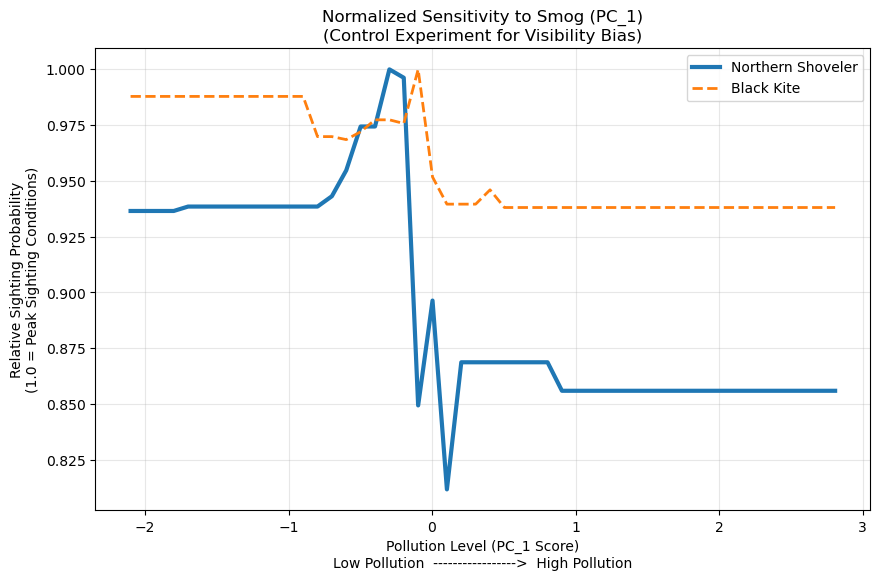

In [ ]:
def run_sensitivity_comparison(df, species_list, feature_cols):
    print("--- Running Sensitivity Control Experiment ---")

    results = []

    # 1. Define Pollution Levels (Clean to Severe Smog)
    # We use PC_1 range from 5th to 95th percentile
    pc1_range = np.linspace(df['PC_1'].quantile(0.05), df['PC_1'].quantile(0.95), 50)

    # 2. Loop through Species
    for bird in species_list:
        print(f"Training model for: {bird}...")

        # A. Prepare Data for this Bird
        sightings = df[df['COMMON NAME'] == bird]['SAMPLING EVENT IDENTIFIER'].unique()
        # Aggregate to checklist level
        # (Optimized: We only need the necessary columns to save memory)
        cols_needed = ['SAMPLING EVENT IDENTIFIER'] + feature_cols
        data = df[cols_needed].drop_duplicates()
        data['TARGET'] = data['SAMPLING EVENT IDENTIFIER'].isin(sightings).astype(int)

        # Handle One-Hot
        if 'TIME_OF_DAY' in data.columns:
            data = pd.get_dummies(data, columns=['TIME_OF_DAY'], drop_first=True)

        X = data.drop(columns=['SAMPLING EVENT IDENTIFIER', 'TARGET'])
        y = data['TARGET']

        # B. Train Model (Quick Random Forest)
        rf = RandomForestClassifier(n_estimators=60, class_weight='balanced', max_depth=7, random_state=42)
        rf.fit(X, y)

        # C. Simulate Smog Impact
        # Create a synthetic dataset where ONLY PC_1 changes
        base_row = X.median().to_frame().T # Average weather/effort

        # Replicate this row 50 times
        sim_data = pd.concat([base_row]*50, ignore_index=True)
        sim_data['PC_1'] = pc1_range

        # Predict Probability
        probs = rf.predict_proba(sim_data)[:, 1]

        # Normalize! (Convert to % of Peak Probability)
        # This allows us to compare a rare bird (max prob 0.2) vs common bird (max prob 0.8)
        normalized_probs = probs / probs.max()

        results.append({
            'Species': bird,
            'PC_1': pc1_range,
            'Probability': normalized_probs
        })

    # 3. Plotting
    plt.figure(figsize=(10, 6))

    for res in results:
        # Style the lines: Dashed for Resident (Control), Solid for Migrant (Target)
        style = '--' if res['Species'] in ['Black Kite', 'House Crow', 'Rock Pigeon'] else '-'
        width = 2 if style == '--' else 3

        plt.plot(res['PC_1'], res['Probability'], linestyle=style, linewidth=width, label=res['Species'])

    plt.title("Normalized Sensitivity to Smog (PC_1)\n(Control Experiment for Visibility Bias)")
    plt.xlabel("Pollution Level (PC_1 Score)\nLow Pollution  ----------------->  High Pollution")
    plt.ylabel("Relative Sighting Probability\n(1.0 = Peak Sighting Conditions)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- EXECUTION ---
# Compare your Migrant vs. a Common Resident
# Make sure 'Black Kite' or 'House Crow' is in your dataset!
comparison_species = ["Northern Shoveler", "Black Kite"]

# Use the feature columns from your previous RF model
run_sensitivity_comparison(df_final, comparison_species, features_to_use)

--- Running Mass Sensitivity Analysis (Logistic Regression) ---
Found 18 valid species in dataset.


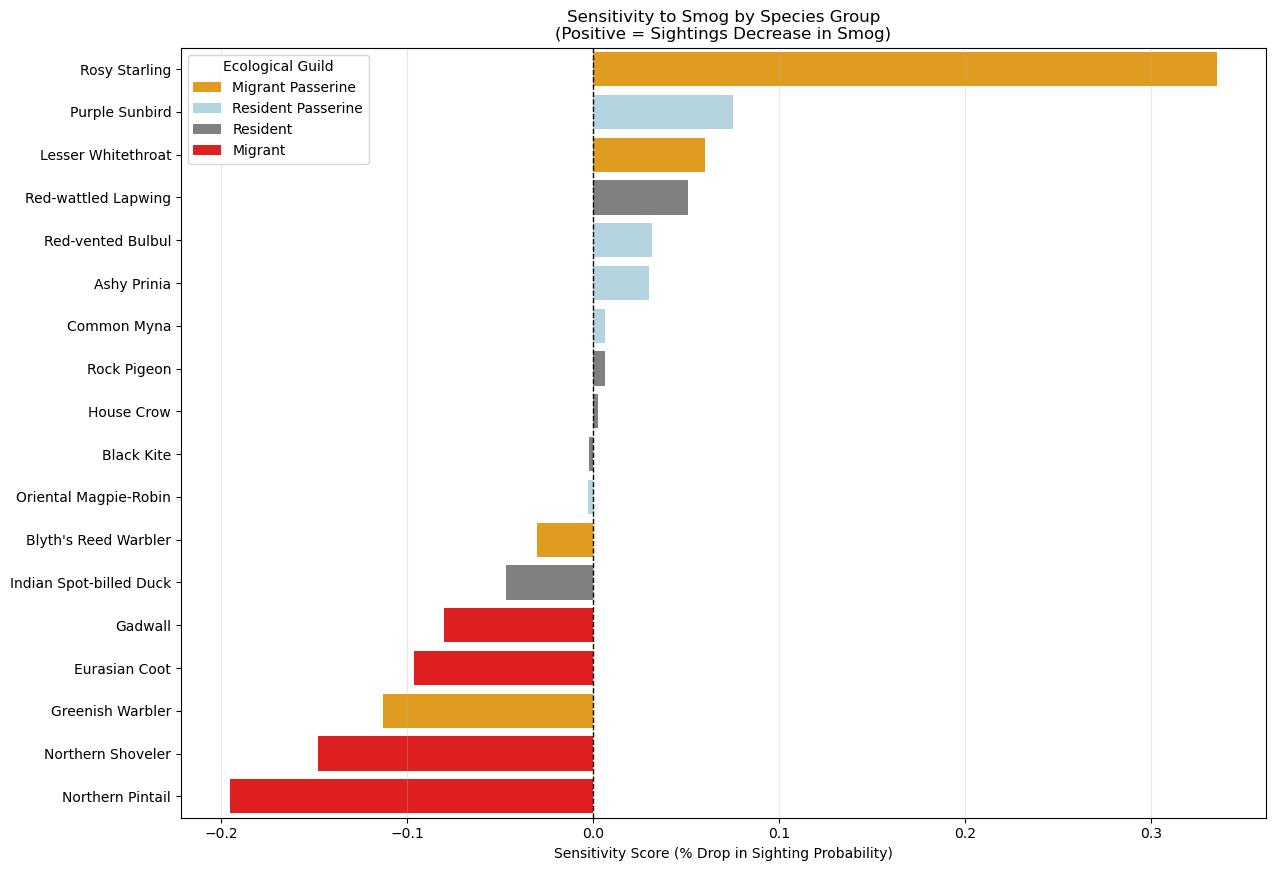

                    Species                Type       P_Value  \
16            Rosy Starling   Migrant Passerine  1.188843e-07   
6            Purple Sunbird  Resident Passerine  6.780927e-12   
17       Lesser Whitethroat   Migrant Passerine  4.728193e-03   
3       Red-wattled Lapwing            Resident  7.452720e-04   
8         Red-vented Bulbul  Resident Passerine  6.694578e-05   
5               Ashy Prinia  Resident Passerine  8.087090e-02   
7               Common Myna  Resident Passerine  1.633032e-01   
2               Rock Pigeon            Resident  1.822175e-01   
1                House Crow            Resident  5.455699e-01   
0                Black Kite            Resident  6.594784e-01   
9     Oriental Magpie-Robin  Resident Passerine  8.379412e-01   
14     Blyth's Reed Warbler   Migrant Passerine  6.057049e-01   
4   Indian Spot-billed Duck            Resident  6.206275e-02   
11                  Gadwall             Migrant  1.197062e-01   
13            Eurasian Co

In [ ]:
# --- STEP 1: DEFINE A ROBUST MIX OF SPECIES ---
species_to_test = {
    # RESIDENTS (The Control Group)
    'Resident': [
        'Black Kite', 'House Crow', 'Rock Pigeon', 'Red-wattled Lapwing',
        'Indian Spot-billed Duck', 'Cattle Egret'
    ],
    # RESIDENT PASSERINES (Small birds, hard to see - Good test for visibility)
    'Resident Passerine': [
        'Ashy Prinia', 'Purple Sunbird', 'Common Myna', 'Red-vented Bulbul', 'Oriental Magpie-Robin'
    ],
    # MIGRANTS (The Test Group)
    'Migrant': [
        'Northern Shoveler', 'Gadwall', 'Northern Pintail', 'Common Teal', 'Eurasian Coot'
    ],
    # MIGRANT PASSERINES (Small migrants)
    'Migrant Passerine': [
        'Blyth\'s Reed Warbler', 'Greenish Warbler', 'Rosy Starling', 'Lesser Whitethroat'
    ]
}

def run_mass_sensitivity_analysis(df, species_dict, feature_cols):
    print("--- Running Mass Sensitivity Analysis (Logistic Regression) ---")
    results = []

    # Flatten species list
    all_species = [bird for cat in species_dict.values() for bird in cat]
    available_species = df['COMMON NAME'].unique()
    valid_species = [s for s in all_species if s in available_species]
    print(f"Found {len(valid_species)} valid species in dataset.")

    smog_feature = 'PC_1'

    for bird in valid_species:
        # 1. Prepare Data
        sightings = df[df['COMMON NAME'] == bird]['SAMPLING EVENT IDENTIFIER'].unique()

        # Filter data & RESET INDEX (Crucial Fix!)
        cols_needed = ['SAMPLING EVENT IDENTIFIER'] + feature_cols
        temp_df = df[cols_needed].drop_duplicates()

        # Reset index to ensure alignment
        temp_df = temp_df.reset_index(drop=True)

        temp_df['TARGET'] = temp_df['SAMPLING EVENT IDENTIFIER'].isin(sightings).astype(int)

        # Skip if too few sightings
        if temp_df['TARGET'].sum() < 50:
            print(f"Skipping {bird}: Not enough sightings ({temp_df['TARGET'].sum()})")
            continue

        # One-Hot Encoding
        if 'TIME_OF_DAY' in temp_df.columns:
            temp_df = pd.get_dummies(temp_df, columns=['TIME_OF_DAY'], drop_first=True)

        # 2. Define X and y
        # Select ONLY numeric columns for X
        X = temp_df.select_dtypes(include=[np.number])
        if 'SAMPLING EVENT IDENTIFIER' in X.columns:
            X = X.drop(columns=['SAMPLING EVENT IDENTIFIER'])
        if 'TARGET' in X.columns:
            X = X.drop(columns=['TARGET'])

        y = temp_df['TARGET']

        # 3. Standardization
        # We preserve the index of X when creating X_scaled
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

        # Add intercept
        X_stats = sm.add_constant(X_scaled)

        try:
            # 4. Run Statistical Model
            model = sm.Logit(y, X_stats).fit(disp=0)

            # Extract stats
            smog_coeff = model.params.get(smog_feature, 0)
            p_value = model.pvalues.get(smog_feature, 1.0)

            # 5. Calculate Sensitivity Drop
            # Create two synthetic rows: Clean Air vs Smog
            row_clean = np.zeros((1, X_stats.shape[1]))
            row_smog = np.zeros((1, X_stats.shape[1]))

            # Set Intercept to 1
            row_clean[0, 0] = 1
            row_smog[0, 0] = 1

            # Set Smog (PC_1) to 10th vs 90th percentile
            if smog_feature in X_stats.columns:
                idx_smog = X_stats.columns.get_loc(smog_feature)
                row_clean[0, idx_smog] = X_scaled[smog_feature].quantile(0.10)
                row_smog[0, idx_smog] = X_scaled[smog_feature].quantile(0.90)

            # Predict
            pred_clean = model.predict(row_clean)[0]
            pred_smog = model.predict(row_smog)[0]

            # Calculate Drop %
            sensitivity = (pred_clean - pred_smog) / pred_clean

            # Identify Category
            category = 'Other'
            for cat, birds in species_dict.items():
                if bird in birds:
                    category = cat

            results.append({
                'Species': bird,
                'Type': category,
                'Smog_Coeff': smog_coeff,
                'P_Value': p_value,
                'Sensitivity_Drop': sensitivity
            })

        except Exception as e:
            print(f"Error modeling {bird}: {e}")

    # --- STEP 3: VISUALIZE ---
    if not results:
        print("No results generated. Check your feature columns or data.")
        return None

    results_df = pd.DataFrame(results).sort_values(by='Sensitivity_Drop', ascending=False)

    plt.figure(figsize=(14, 10))

    palette = {
        'Migrant': 'red',
        'Migrant Passerine': 'orange',
        'Resident': 'gray',
        'Resident Passerine': 'lightblue'
    }

    sns.barplot(data=results_df, y='Species', x='Sensitivity_Drop', hue='Type',
                palette=palette, dodge=False)

    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.title("Sensitivity to Smog by Species Group\n(Positive = Sightings Decrease in Smog)")
    plt.xlabel("Sensitivity Score (% Drop in Sighting Probability)")
    plt.ylabel("")
    plt.legend(title="Ecological Guild")
    plt.grid(axis='x', alpha=0.3)
    plt.show()

    return results_df

# --- EXECUTION ---
# Run the analysis
stats_report = run_mass_sensitivity_analysis(df_final, species_to_test, features_to_use)
if stats_report is not None:
    print(stats_report[['Species', 'Type', 'P_Value', 'Sensitivity_Drop']])

In [ ]:
import folium
from folium.plugins import HeatMap

🦅 Generating Custom Gradient Map for: Northern Shoveler...
📂 Loading shapefile from: C:\Users\MSI-1\Downloads\4ed2aafb493f3af53e554b9384ef07c7-1b6219722435be6f9aef4af2df10ec738e416ca2\4ed2aafb493f3af53e554b9384ef07c7-1b6219722435be6f9aef4af2df10ec738e416ca2\delhi-ac.geojson


C:\Users\MSI-1\AppData\Local\Temp\ipykernel_34156\194424524.py:28: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  delhi_boundary = delhi_gdf.unary_union


✅ Official Delhi Boundary loaded successfully.
📍 Calculating surface probabilities...


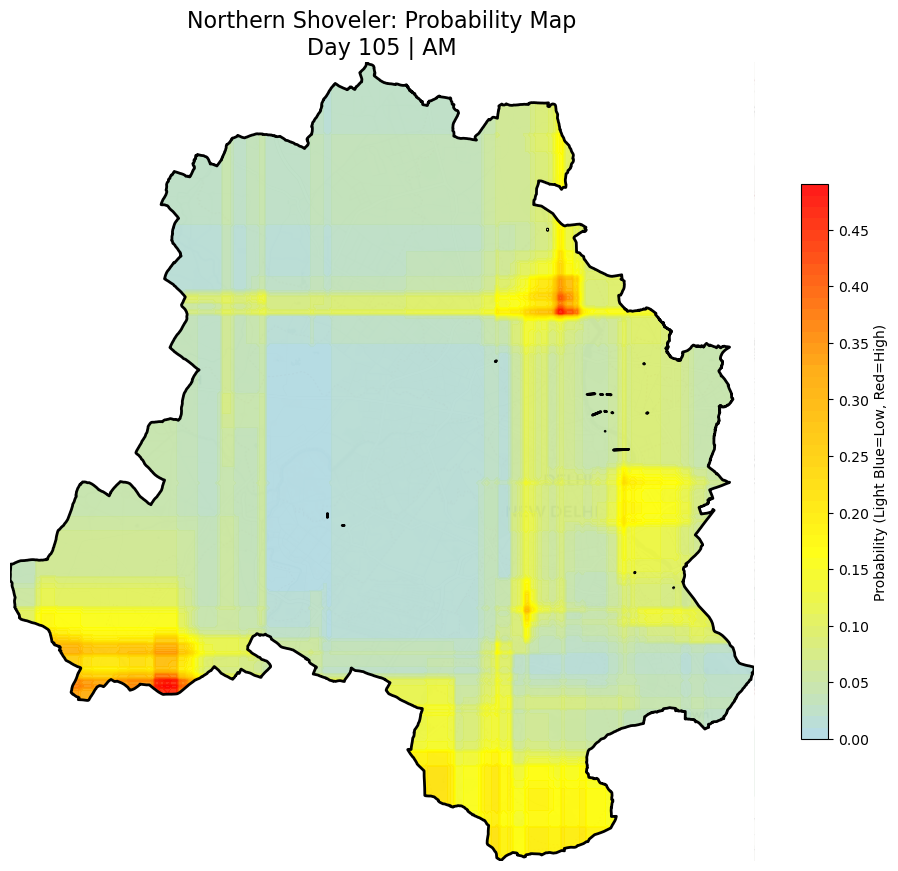

In [ ]:
def predict_official_shape_map(species_name, day_of_season, time_of_day, df, trained_model, shapefile_path):
    print(f"🦅 Generating Custom Gradient Map for: {species_name}...")

    # --- 1. DEFINE CUSTOM COLORMAP ---
    # 0.0 (Low Prob) -> Light Blue
    # Transition -> Yellow
    # Transition -> Orange
    # 1.0 (High Prob) -> Red
    colors = ["lightblue", "yellow", "orange", "red"]
    custom_cmap = LinearSegmentedColormap.from_list("blue_yellow_red", colors)

    # --- 2. LOAD & FILTER SHAPEFILE ---
    print(f"📂 Loading shapefile from: {shapefile_path}")
    try:
        gdf_all = gpd.read_file(shapefile_path)

        # Filter for Delhi (Robust Check)
        if 'NAME_1' in gdf_all.columns:
            delhi_gdf = gdf_all[gdf_all['NAME_1'] == 'NCT of Delhi']
        elif 'ST_NM' in gdf_all.columns:
            delhi_gdf = gdf_all[gdf_all['ST_NM'] == 'NCT of Delhi']
        elif 'dtname' in gdf_all.columns:
             delhi_gdf = gdf_all[gdf_all['dtname'].str.contains('Delhi', case=False)]
        else:
            # Fallback: Filter by coordinates
            delhi_gdf = gdf_all.cx[76.8:77.3, 28.4:28.9]

        delhi_boundary = delhi_gdf.unary_union

        # Reproject to Web Mercator
        delhi_gdf_merc = gpd.GeoDataFrame(geometry=[delhi_boundary], crs="EPSG:4326").to_crs(epsg=3857)
        delhi_shape_merc = delhi_gdf_merc.geometry[0]

        print("✅ Official Delhi Boundary loaded successfully.")

    except Exception as e:
        print(f"❌ Error loading shapefile: {e}")
        return

    # --- 3. GENERATE GRID ---
    minx, miny, maxx, maxy = delhi_boundary.bounds

    grid_res = 300
    pad = 0.01
    x_axis = np.linspace(minx - pad, maxx + pad, grid_res)
    y_axis = np.linspace(miny - pad, maxy + pad, grid_res)
    xv, yv = np.meshgrid(x_axis, y_axis)

    grid_df = pd.DataFrame({'LONGITUDE': xv.ravel(), 'LATITUDE': yv.ravel()})

    # --- 4. PREPARE FEATURES ---
    print("📍 Calculating surface probabilities...")
    model_features = trained_model.feature_names_in_
    current_week = day_of_season // 7
    weekly_weather = df[df['SEASON_WEEK'] == current_week][['PC_1', 'PC_2', 'PC_3', 'PC_4']].median()

    pred_df = grid_df.copy()
    for feature in model_features:
        if feature in ['PC_1', 'PC_2', 'PC_3', 'PC_4']:
            pred_df[feature] = weekly_weather.get(feature, 0)
        elif feature == 'SEASON_WEEK':
            pred_df[feature] = current_week
        elif 'TIME_OF_DAY' in feature:
            target_col = f"TIME_OF_DAY_{time_of_day}"
            pred_df[feature] = 1 if feature == target_col else 0
        elif feature == 'DURATION MINUTES':
            pred_df[feature] = df['DURATION MINUTES'].median()
        elif feature == 'EFFORT DISTANCE KM':
            pred_df[feature] = df['EFFORT DISTANCE KM'].median()
        elif feature not in pred_df.columns:
            pred_df[feature] = 0
    pred_df = pred_df[model_features]

    # --- 5. PREDICT ---
    probs = trained_model.predict_proba(pred_df)[:, 1]

    # --- 6. VISUALIZE ---
    gdf_plot = gpd.GeoDataFrame(pred_df, geometry=gpd.points_from_xy(grid_df.LONGITUDE, grid_df.LATITUDE), crs="EPSG:4326")
    gdf_plot['prob'] = probs
    gdf_plot = gdf_plot.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(12, 12))

    # A. Plot Heatmap with CUSTOM CMAP
    x_merc = gdf_plot.geometry.x
    y_merc = gdf_plot.geometry.y
    cntr = ax.tricontourf(x_merc, y_merc, gdf_plot['prob'],
                          levels=60, cmap=custom_cmap, alpha=0.9)

    # B. Add Basemap
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    except:
        pass

    # C. Inverted Mask
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    giant_rect = box(xlim[0], ylim[0], xlim[1], ylim[1])

    inverted_mask = giant_rect.difference(delhi_shape_merc)

    # Plot White Mask
    gpd.GeoSeries([inverted_mask]).plot(ax=ax, color='white', edgecolor='none', zorder=10)

    # Plot Outline
    gpd.GeoSeries([delhi_shape_merc]).plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2, zorder=11)

    # Formatting
    cbar = plt.colorbar(cntr, ax=ax, shrink=0.6)
    cbar.set_label(f"Probability (Light Blue=Low, Red=High)")

    ax.set_title(f"{species_name}: Probability Map\nDay {day_of_season} | {time_of_day}", fontsize=16)
    ax.axis('off')

    # Zoom
    minx_m, miny_m, maxx_m, maxy_m = delhi_shape_merc.bounds
    ax.set_xlim(minx_m, maxx_m)
    ax.set_ylim(miny_m, maxy_m)

    plt.show()

# --- EXECUTION ---
# NOTE: Use the exact path to the file you uploaded
predict_official_shape_map("Northern Shoveler", day_of_season=105, time_of_day='AM',
                           df=df_final, trained_model=rf_best,
                           shapefile_path="C:\\Users\\MSI-1\\Downloads\\4ed2aafb493f3af53e554b9384ef07c7-1b6219722435be6f9aef4af2df10ec738e416ca2\\4ed2aafb493f3af53e554b9384ef07c7-1b6219722435be6f9aef4af2df10ec738e416ca2\\delhi-ac.geojson")

In [ ]:
from ipywidgets import interact, IntSlider, Play, jslink, HBox, VBox
from shapely.prepared import prep

In [ ]:
# --- STEP 1: WEATHER INTERPOLATION (Smoother transitions) ---
def get_smooth_daily_weather(df):
    print("🌊 Interpolating weather for smooth animation...")
    weekly_weather = df.groupby('SEASON_WEEK')[['PC_1', 'PC_2', 'PC_3', 'PC_4']].median().reset_index()
    weekly_weather['day_center'] = weekly_weather['SEASON_WEEK'] * 7 - 3
    daily_df = pd.DataFrame({'DAY': range(1, 181)})
    merged = pd.merge(daily_df, weekly_weather, left_on='DAY', right_on='day_center', how='left')
    merged.iloc[0, 2:] = merged.iloc[0, 2:].fillna(weekly_weather.iloc[0, 1:-1])
    merged.iloc[-1, 2:] = merged.iloc[-1, 2:].fillna(weekly_weather.iloc[-1, 1:-1])
    smooth_weather = merged[['PC_1', 'PC_2', 'PC_3', 'PC_4']].interpolate(method='cubic').ffill().bfill()
    smooth_weather['DAY'] = daily_df['DAY']
    return smooth_weather

# --- STEP 2: PRE-CALCULATE FRAMES WITH MASK ---
def generate_masked_frames(species_name, time_of_day, df, trained_model, shapefile_path, grid_res=150):
    print(f"🎥 Generating masked frames for {species_name}...")

    # A. Load & Prepare Boundary
    print("   Loading boundary...")
    try:
        gdf_all = gpd.read_file(shapefile_path)
        # Flexible filtering for Delhi
        if 'NAME_1' in gdf_all.columns:
            delhi_gdf = gdf_all[gdf_all['NAME_1'] == 'NCT of Delhi']
        elif 'ST_NM' in gdf_all.columns:
            delhi_gdf = gdf_all[gdf_all['ST_NM'] == 'NCT of Delhi']
        elif 'dtname' in gdf_all.columns:
             delhi_gdf = gdf_all[gdf_all['dtname'].str.contains('Delhi', case=False)]
        else:
            delhi_gdf = gdf_all.cx[76.8:77.3, 28.4:28.9] # Fallback coords

        delhi_boundary = delhi_gdf.unary_union
        # Work in Web Mercator for correct shape/projection
        delhi_merc_gdf = gpd.GeoDataFrame(geometry=[delhi_boundary], crs="EPSG:4326").to_crs(epsg=3857)
        delhi_shape = delhi_merc_gdf.geometry[0]

    except Exception as e:
        print(f"❌ Error: {e}")
        return None, None, None

    # B. Create Grid & Mask
    print("   Creating clipping mask (this ensures the 'Delhi Shape')...")
    minx, miny, maxx, maxy = delhi_shape.bounds
    x_axis = np.linspace(minx, maxx, grid_res)
    y_axis = np.linspace(miny, maxy, grid_res)
    xv, yv = np.meshgrid(x_axis, y_axis)

    # 1. Create a list of points from the grid
    grid_points_merc = [Point(x, y) for x, y in zip(xv.ravel(), yv.ravel())]

    # 2. Check which points are inside Delhi (Fast check using 'prepared' geometry)
    prepared_shape = prep(delhi_shape)
    mask = np.array([prepared_shape.contains(p) for p in grid_points_merc])
    mask_grid = mask.reshape(grid_res, grid_res)

    # C. Convert Grid to Lat/Lon for Prediction
    # (The model was trained on Lat/Lon, so we must predict on Lat/Lon)
    temp_gdf = gpd.GeoDataFrame(geometry=grid_points_merc, crs="EPSG:3857").to_crs("EPSG:4326")
    pred_lons = temp_gdf.geometry.x.values
    pred_lats = temp_gdf.geometry.y.values

    grid_df_model = pd.DataFrame({'LONGITUDE': pred_lons, 'LATITUDE': pred_lats})

    # D. Prepare Weather & Features
    smooth_weather = get_smooth_daily_weather(df)
    model_features = trained_model.feature_names_in_

    base_df = grid_df_model.copy()
    # Fill constants
    for feature in model_features:
        if feature == 'DURATION MINUTES':
            base_df[feature] = df['DURATION MINUTES'].median()
        elif feature == 'EFFORT DISTANCE KM':
            base_df[feature] = df['EFFORT DISTANCE KM'].median()
        elif 'TIME_OF_DAY' in feature:
            target_col = f"TIME_OF_DAY_{time_of_day}"
            base_df[feature] = 1 if feature == target_col else 0
        elif feature not in base_df.columns:
            base_df[feature] = 0 # placeholders for weather/season

    # E. Generate 180 Frames
    frames = []
    print("   Calculating 180 days of predictions...")

    for day in range(1, 181):
        # Update dynamic features
        current_weather = smooth_weather[smooth_weather['DAY'] == day].iloc[0]

        step_df = base_df.copy()
        step_df['SEASON_WEEK'] = day // 7
        step_df['PC_1'] = current_weather['PC_1']
        step_df['PC_2'] = current_weather['PC_2']
        step_df['PC_3'] = current_weather['PC_3']
        step_df['PC_4'] = current_weather['PC_4']

        # Predict
        probs = trained_model.predict_proba(step_df[model_features])[:, 1]
        prob_grid = probs.reshape(grid_res, grid_res)

        # APPLY MASK: Set outside points to NaN so they don't plot
        prob_grid[~mask_grid] = np.nan

        frames.append(prob_grid)

        if day % 45 == 0: print(f"    ...Day {day}")

    return frames, delhi_merc_gdf, (xv, yv)

# --- STEP 3: THE PLAYER ---
def play_masked_animation(species_name, frames, boundary_gdf, grid_mesh):
    print("🚀 Loading Player...")

    xv, yv = grid_mesh

    # Custom Colors
    colors = ["lightblue", "yellow", "orange", "red"]
    custom_cmap = LinearSegmentedColormap.from_list("custom", colors)

    def update_plot(day):
        fig, ax = plt.subplots(figsize=(10, 10))

        # 1. Plot the Boundary Outline (Black Line)
        boundary_gdf.boundary.plot(ax=ax, color='black', linewidth=2, zorder=5)

        # 2. Plot the Heatmap
        # Since we set outside points to NaN, contourf will inherently clip to the shape!
        frame_data = frames[day-1]
        cntr = ax.contourf(xv, yv, frame_data, levels=40, cmap=custom_cmap, vmin=0, vmax=1)

        # Styling
        ax.set_title(f"{species_name}: Day {day} (Oct-Mar)", fontsize=15)
        ax.axis('off') # Remove box

        # Lock zoom
        minx, miny, maxx, maxy = boundary_gdf.total_bounds
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)

        plt.show()

    # Controls
    slider = IntSlider(min=1, max=180, step=1, value=1, description='Day')
    play = Play(min=1, max=180, step=1, interval=100)
    jslink((play, 'value'), (slider, 'value'))
    ui = HBox([play, slider])

    interact(update_plot, day=slider)
    display(ui)

# --- EXECUTION ---
# 1. Calculate
frames, boundary_gdf, mesh = generate_masked_frames(
    "Northern Shoveler", "AM", df_final, rf_best, "C:\\Users\MSI-1\\Downloads\\4ed2aafb493f3af53e554b9384ef07c7-1b6219722435be6f9aef4af2df10ec738e416ca2\\4ed2aafb493f3af53e554b9384ef07c7-1b6219722435be6f9aef4af2df10ec738e416ca2\\delhi-ac.geojson")

# 2. Play
if frames is not None:
    play_masked_animation("Northern Shoveler", frames, boundary_gdf, mesh)

🎥 Generating masked frames for Northern Shoveler...
   Loading boundary...


C:\Users\MSI-1\AppData\Local\Temp\ipykernel_34156\231076593.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  delhi_boundary = delhi_gdf.unary_union


   Creating clipping mask (this ensures the 'Delhi Shape')...
🌊 Interpolating weather for smooth animation...
   Calculating 180 days of predictions...
    ...Day 45
    ...Day 90
    ...Day 135
    ...Day 180
🚀 Loading Player...


interactive(children=(IntSlider(value=1, description='Day', max=180, min=1), Output()), _dom_classes=('widget-…

In [ ]:
# --- 1. TRAINER HELPER (Champion Settings) ---
def train_bird_model(species_name, df, feature_cols):
    print(f"🧠 Training CHAMPION MODEL (Full Power) for: {species_name}...")

    # Filter data
    sightings = df[df['COMMON NAME'] == species_name]['SAMPLING EVENT IDENTIFIER'].unique()
    if len(sightings) < 10:
        print(f"⚠️ Error: Not enough data for {species_name}.")
        return None

    data = df[['SAMPLING EVENT IDENTIFIER'] + feature_cols].drop_duplicates()
    data['TARGET'] = data['SAMPLING EVENT IDENTIFIER'].isin(sightings).astype(int)

    if 'TIME_OF_DAY' in data.columns:
        data = pd.get_dummies(data, columns=['TIME_OF_DAY'], drop_first=True)

    X = data.drop(columns=['SAMPLING EVENT IDENTIFIER', 'TARGET'])
    y = data['TARGET']

    # Champion Settings
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf.fit(X, y)

    return rf

# --- 2. MASTER FUNCTION (Corrected Feature Selection) ---
def animate_species_migration(species_name, df, shapefile_path):

    # A. DEFINE FEATURES (EXACTLY AS YOU DID BEFORE)
    # We dynamically grab all PCA columns + the standard context columns
    pca_cols = [col for col in df.columns if col.startswith('PC_')]
    context_cols = ['SEASON_WEEK', 'LATITUDE', 'LONGITUDE',
                    'DURATION MINUTES', 'EFFORT DISTANCE KM', 'TIME_OF_DAY']

    features_to_use = pca_cols + context_cols

    # B. Train Model
    custom_model = train_bird_model(species_name, df, features_to_use)

    if custom_model is None:
        return

    # C. Generate Frames
    frames, boundary_gdf, mesh = generate_masked_frames(
        species_name, "AM", df, custom_model, shapefile_path
    )

    # D. Play Animation
    if frames is not None:
        play_masked_animation(species_name, frames, boundary_gdf, mesh)

# ==========================================
# EXECUTION
# ==========================================

# Path to your shapefile
delhi_shape_path = r"C:\Users\MSI-1\Downloads\4ed2aafb493f3af53e554b9384ef07c7-1b6219722435be6f9aef4af2df10ec738e416ca2\4ed2aafb493f3af53e554b9384ef07c7-1b6219722435be6f9aef4af2df10ec738e416ca2\delhi-ac.geojson"

# 1. The Migrant Duck
print("--- ANIMATION 1: NORTHERN SHOVELER ---")
animate_species_migration("Northern Shoveler", df_final, delhi_shape_path)

# 2. The Resident Raptor
print("\n--- ANIMATION 2: BLACK KITE ---")
animate_species_migration("Black Kite", df_final, delhi_shape_path)

--- ANIMATION 1: NORTHERN SHOVELER ---
🧠 Training CHAMPION MODEL (Full Power) for: Northern Shoveler...
🎥 Generating masked frames for Northern Shoveler...
   Loading boundary...


C:\Users\MSI-1\AppData\Local\Temp\ipykernel_34156\231076593.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  delhi_boundary = delhi_gdf.unary_union


   Creating clipping mask (this ensures the 'Delhi Shape')...
🌊 Interpolating weather for smooth animation...
   Calculating 180 days of predictions...
    ...Day 45
    ...Day 90
    ...Day 135
    ...Day 180
🚀 Loading Player...


interactive(children=(IntSlider(value=1, description='Day', max=180, min=1), Output()), _dom_classes=('widget-…


--- ANIMATION 2: BLACK KITE ---
🧠 Training CHAMPION MODEL (Full Power) for: Black Kite...
🎥 Generating masked frames for Black Kite...
   Loading boundary...


C:\Users\MSI-1\AppData\Local\Temp\ipykernel_34156\231076593.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  delhi_boundary = delhi_gdf.unary_union


   Creating clipping mask (this ensures the 'Delhi Shape')...
🌊 Interpolating weather for smooth animation...
   Calculating 180 days of predictions...
    ...Day 45
    ...Day 90
    ...Day 135
    ...Day 180
🚀 Loading Player...


interactive(children=(IntSlider(value=1, description='Day', max=180, min=1), Output()), _dom_classes=('widget-…

In [ ]:
print("\n--- ANIMATION 2: BLACK KITE ---")
animate_species_migration("Rosy Starling", df_final, delhi_shape_path)


--- ANIMATION 2: BLACK KITE ---
🧠 Training CHAMPION MODEL (Full Power) for: Rosy Starling...
🎥 Generating masked frames for Rosy Starling...
   Loading boundary...


C:\Users\MSI-1\AppData\Local\Temp\ipykernel_34156\231076593.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  delhi_boundary = delhi_gdf.unary_union


   Creating clipping mask (this ensures the 'Delhi Shape')...
🌊 Interpolating weather for smooth animation...
   Calculating 180 days of predictions...
    ...Day 45
    ...Day 90
    ...Day 135
    ...Day 180
🚀 Loading Player...


interactive(children=(IntSlider(value=1, description='Day', max=180, min=1), Output()), _dom_classes=('widget-…

In [ ]:
print("\n--- ANIMATION 2: BLACK KITE ---")
animate_species_migration("Black-headed gull", df_final, delhi_shape_path)


--- ANIMATION 2: BLACK KITE ---
🧠 Training CHAMPION MODEL (Full Power) for: Black-headed gull...
⚠️ Error: Not enough data for Black-headed gull.


In [ ]:
print("\n--- ANIMATION 2: BLACK KITE ---")
animate_species_migration("Bluethroat", df_final, delhi_shape_path)


--- ANIMATION 2: BLACK KITE ---
🧠 Training CHAMPION MODEL (Full Power) for: Bluethroat...
🎥 Generating masked frames for Bluethroat...
   Loading boundary...


C:\Users\MSI-1\AppData\Local\Temp\ipykernel_34156\231076593.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  delhi_boundary = delhi_gdf.unary_union


   Creating clipping mask (this ensures the 'Delhi Shape')...
🌊 Interpolating weather for smooth animation...
   Calculating 180 days of predictions...
    ...Day 45
    ...Day 90
    ...Day 135
    ...Day 180
🚀 Loading Player...


interactive(children=(IntSlider(value=1, description='Day', max=180, min=1), Output()), _dom_classes=('widget-…

In [ ]:
animate_species_migration("Ruff", df_final, delhi_shape_path)

🧠 Training CHAMPION MODEL (Full Power) for: Ruff...
🎥 Generating masked frames for Ruff...
   Loading boundary...


C:\Users\MSI-1\AppData\Local\Temp\ipykernel_34156\231076593.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  delhi_boundary = delhi_gdf.unary_union


   Creating clipping mask (this ensures the 'Delhi Shape')...
🌊 Interpolating weather for smooth animation...
   Calculating 180 days of predictions...
    ...Day 45
    ...Day 90
    ...Day 135
    ...Day 180
🚀 Loading Player...


interactive(children=(IntSlider(value=1, description='Day', max=180, min=1), Output()), _dom_classes=('widget-…

In [ ]:
animate_species_migration("Osprey", df_final, delhi_shape_path)

🧠 Training CHAMPION MODEL (Full Power) for: Osprey...
🎥 Generating masked frames for Osprey...
   Loading boundary...


C:\Users\MSI-1\AppData\Local\Temp\ipykernel_34156\231076593.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  delhi_boundary = delhi_gdf.unary_union


   Creating clipping mask (this ensures the 'Delhi Shape')...
🌊 Interpolating weather for smooth animation...
   Calculating 180 days of predictions...
    ...Day 45
    ...Day 90
    ...Day 135
    ...Day 180
🚀 Loading Player...


interactive(children=(IntSlider(value=1, description='Day', max=180, min=1), Output()), _dom_classes=('widget-…

In [ ]:
animate_species_migration("Greater Flamingo", df_final, delhi_shape_path)

In [ ]:
# --- 1. TRAINER HELPER (Champion Model) ---
def train_bird_model(species_name, df, feature_cols):
    print(f"   🧠 Training model for: {species_name}...")

    # Filter data
    sightings = df[df['COMMON NAME'] == species_name]['SAMPLING EVENT IDENTIFIER'].unique()
    if len(sightings) < 10:
        print(f"   ⚠️ Error: Not enough data ({len(sightings)} sightings). Skipping.")
        return None

    data = df[['SAMPLING EVENT IDENTIFIER'] + feature_cols].drop_duplicates()
    data['TARGET'] = data['SAMPLING EVENT IDENTIFIER'].isin(sightings).astype(int)

    if 'TIME_OF_DAY' in data.columns:
        data = pd.get_dummies(data, columns=['TIME_OF_DAY'], drop_first=True)

    X = data.drop(columns=['SAMPLING EVENT IDENTIFIER', 'TARGET'])
    y = data['TARGET']

    # Champion Settings
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X, y)

    return rf

# --- 2. FRAME GENERATOR (Pre-calculates 180 days) ---
# (This is the same robust function from before)
def generate_masked_frames(species_name, time_of_day, df, trained_model, shapefile_path, grid_res=150):
    print(f"   🎥 Generating frames...")

    # A. Load Boundary
    try:
        gdf_all = gpd.read_file(shapefile_path)
        # Smart Filter
        if 'NAME_1' in gdf_all.columns:
            delhi_gdf = gdf_all[gdf_all['NAME_1'] == 'NCT of Delhi']
        elif 'ST_NM' in gdf_all.columns:
            delhi_gdf = gdf_all[gdf_all['ST_NM'] == 'NCT of Delhi']
        elif 'dtname' in gdf_all.columns:
             delhi_gdf = gdf_all[gdf_all['dtname'].str.contains('Delhi', case=False)]
        else:
            delhi_gdf = gdf_all.cx[76.8:77.3, 28.4:28.9]

        delhi_boundary = delhi_gdf.unary_union
        delhi_merc_gdf = gpd.GeoDataFrame(geometry=[delhi_boundary], crs="EPSG:4326").to_crs(epsg=3857)
        delhi_shape = delhi_merc_gdf.geometry[0]
    except Exception as e:
        print(f"   ❌ Map Error: {e}")
        return None, None, None

    # B. Create Grid & Mask
    minx, miny, maxx, maxy = delhi_shape.bounds
    x_axis = np.linspace(minx, maxx, grid_res)
    y_axis = np.linspace(miny, maxy, grid_res)
    xv, yv = np.meshgrid(x_axis, y_axis)

    from shapely.geometry import Point
    from shapely.prepared import prep

    grid_points = [Point(x, y) for x, y in zip(xv.ravel(), yv.ravel())]
    prepared_shape = prep(delhi_shape)
    mask = np.array([prepared_shape.contains(p) for p in grid_points])
    mask_grid = mask.reshape(grid_res, grid_res)

    # Lat/Lon conversion for Model
    temp_gdf = gpd.GeoDataFrame(geometry=grid_points, crs="EPSG:3857").to_crs("EPSG:4326")
    grid_df_model = pd.DataFrame({'LONGITUDE': temp_gdf.geometry.x, 'LATITUDE': temp_gdf.geometry.y})

    # C. Weather & Constants
    # (Inline interpolation for speed)
    weekly_weather = df.groupby('SEASON_WEEK')[['PC_1', 'PC_2', 'PC_3', 'PC_4']].median().reset_index()
    weekly_weather['day_center'] = weekly_weather['SEASON_WEEK'] * 7 - 3
    daily_df = pd.DataFrame({'DAY': range(1, 181)})
    merged = pd.merge(daily_df, weekly_weather, left_on='DAY', right_on='day_center', how='left')
    merged.iloc[0, 2:] = merged.iloc[0, 2:].fillna(weekly_weather.iloc[0, 1:-1])
    merged.iloc[-1, 2:] = merged.iloc[-1, 2:].fillna(weekly_weather.iloc[-1, 1:-1])
    smooth_weather = merged[['PC_1', 'PC_2', 'PC_3', 'PC_4']].interpolate(method='cubic').ffill().bfill()
    smooth_weather['DAY'] = daily_df['DAY']

    model_features = trained_model.feature_names_in_
    base_df = grid_df_model.copy()

    # Fill static features
    for feature in model_features:
        if feature == 'DURATION MINUTES': base_df[feature] = df['DURATION MINUTES'].median()
        elif feature == 'EFFORT DISTANCE KM': base_df[feature] = df['EFFORT DISTANCE KM'].median()
        elif 'TIME_OF_DAY' in feature:
            target_col = f"TIME_OF_DAY_{time_of_day}"
            base_df[feature] = 1 if feature == target_col else 0
        elif feature not in base_df.columns: base_df[feature] = 0

    frames = []

    # Loop days
    for day in range(1, 181):
        current_weather = smooth_weather[smooth_weather['DAY'] == day].iloc[0]
        step_df = base_df.copy()
        step_df['SEASON_WEEK'] = day // 7
        step_df['PC_1'] = current_weather['PC_1']
        step_df['PC_2'] = current_weather['PC_2']
        step_df['PC_3'] = current_weather['PC_3']
        step_df['PC_4'] = current_weather['PC_4']

        # Predict
        probs = trained_model.predict_proba(step_df[model_features])[:, 1]
        prob_grid = probs.reshape(grid_res, grid_res)
        prob_grid[~mask_grid] = np.nan # Mask outside Delhi
        frames.append(prob_grid)

    return frames, delhi_merc_gdf, (xv, yv)

# --- 3. VIDEO SAVER FUNCTION ---
def save_video_for_species(species_name, frames, boundary_gdf, mesh, output_folder):
    print(f"   💾 Saving video to: {output_folder}")

    xv, yv = mesh

    # Custom Colors
    colors = ["lightblue", "yellow", "orange", "red"]
    custom_cmap = LinearSegmentedColormap.from_list("custom", colors)

    # Setup Figure
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot Boundary (Static)
    boundary_gdf.boundary.plot(ax=ax, color='black', linewidth=2, zorder=5)

    # Lock Zoom
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.axis('off')

    # Title Placeholder
    title = ax.set_title(f"{species_name}: Day 1", fontsize=15)

    # Initial Plot (will be updated)
    # We must assign vmin/vmax to keep colors consistent across frames
    contour = ax.contourf(xv, yv, frames[0], levels=40, cmap=custom_cmap, vmin=0, vmax=1)

    # Animation Update Function
    def animate(i):
        ax.clear()
        # Re-plot boundary and map for each frame
        boundary_gdf.boundary.plot(ax=ax, color='black', linewidth=2, zorder=5)
        ax.contourf(xv, yv, frames[i], levels=40, cmap=custom_cmap, vmin=0, vmax=1)
        ax.set_title(f"{species_name}: Day {i+1} (Oct-Mar)", fontsize=15)
        ax.axis('off')
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        return ax,

    # Create Animation Object
    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=100)

    # Ensure output directory exists
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Save File
    filename = f"{species_name}_Migration.mp4"
    filepath = os.path.join(output_folder, filename)

    try:
        # Try saving as MP4 (Requires FFmpeg)
        writer = animation.FFMpegWriter(fps=15, metadata=dict(artist='Me'), bitrate=1800)
        anim.save(filepath, writer=writer)
        print(f"   ✅ Saved: {filepath}")
    except Exception as e:
        print(f"   ⚠️ MP4 failed (FFmpeg not found?). Saving as GIF instead...")
        filepath = filepath.replace('.mp4', '.gif')
        writer = animation.PillowWriter(fps=15)
        anim.save(filepath, writer=writer)
        print(f"   ✅ Saved GIF: {filepath}")

    plt.close(fig) # Close plot to save memory

# --- 4. BATCH PROCESSOR (The Main Loop) ---
def process_species_list(species_list, df, shapefile_path, output_folder):
    print(f"🚀 Starting Batch Processing for {len(species_list)} species...")

    # Define Features
    pca_cols = [col for col in df.columns if col.startswith('PC_')]
    context_cols = ['SEASON_WEEK', 'LATITUDE', 'LONGITUDE', 'DURATION MINUTES', 'EFFORT DISTANCE KM', 'TIME_OF_DAY']
    features = pca_cols + context_cols

    for i, bird in enumerate(species_list):
        print(f"\n🐦 Processing {i+1}/{len(species_list)}: {bird}")

        # A. Train
        model = train_bird_model(bird, df, features)
        if model is None: continue

        # B. Generate
        frames, boundary, mesh = generate_masked_frames(bird, "AM", df, model, shapefile_path)
        if frames is None: continue

        # C. Save
        save_video_for_species(bird, frames, boundary, mesh, output_folder)

    print("\n🎉 Batch Processing Complete! Check your folder.")

# ==========================================
# EXECUTION CONFIGURATION
# ==========================================

# 1. Your Shapefile Path
my_shapefile = r"C:\Users\MSI-1\Downloads\4ed2aafb493f3af53e554b9384ef07c7-1b6219722435be6f9aef4af2df10ec738e416ca2\4ed2aafb493f3af53e554b9384ef07c7-1b6219722435be6f9aef4af2df10ec738e416ca2\delhi-ac.geojson"

# 2. Your Output Folder (Change 'YourName' or use simple path)
# Note: Using 'r' before the string handles backslashes correctly
my_output_folder = r"C:\Users\MSI-1\OneDrive\Desktop\Geospatial - temporal maps"

# 3. Your List of Birds
my_birds = [
    "Northern Shoveler",
    "Black Kite",
    "Gadwall",
    "Northern Pintail",
    "Eurasian Coot",
    "Wood Sandpiper",
    "Citrine Wagtail",
    "Bluethroat",
    "Rosy Starling",
    "Greenish Warbler"
]

# 4. RUN!
process_species_list(my_birds, df_final, my_shapefile, my_output_folder)